# Hopfield LLM — Category × Layer Signal Analysis

**Motivation (from NB01):** The global AUROC of Δ Energy is weak (~0.47–0.54), but the per-category AUROC heatmap shows extreme variation — up to 1.00 for some (LLaMA/Misquotations) and down to 0.00 (LLaMA/Education).  
This notebook investigates whether the thermodynamic retrieval signal is *category-specific* and *layer-specific*:

1. **Category AUROC with confidence intervals** — which categories have reliable signal?
2. **Category × Layer heatmap** — which (category, layer) combinations are hot?
3. **AUROC[L] curves per category** — where in the network does each topic discriminate?
4. **Multi-layer logistic probe per category** — does combining layers beat the best single layer?
5. **Layer profile clustering (PCA)** — are categories with similar AUROC thermodynamically similar?

**Models:** Qwen 2.5 3B (36 layers) · LLaMA 3.2 3B (28 layers)  
**Dataset:** TruthfulQA 500 samples, seed=42  
**Labels:** GPT-4o-mini judge (binary)


## 0 — Imports & Config

In [1]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

EXPERIMENTS = {
    'Qwen 2.5 3B':  Path('/home/brandon/viz/20260424_153142_qwen25_3b_truthfulqa_up_b15.0_a2dfcc'),
    'LLaMA 3.2 3B': Path('/home/brandon/viz/20260424_191203_llama32_3b_truthfulqa_up_b15.0_0ea592'),
}
CATEGORIES_PATH = Path('../data/truthfulqa_categories.json')
PLOTS_DIR = Path('../outputs/presentation_plots/nb02')
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

N_LAYERS      = {'Qwen 2.5 3B': 36, 'LLaMA 3.2 3B': 28}
MODEL_COLORS  = {'Qwen 2.5 3B': '#3498db', 'LLaMA 3.2 3B': '#9b59b6'}
COLORS        = {'OK': '#2ecc71', 'HAL': '#e74c3c'}
models        = list(EXPERIMENTS.keys())
MIN_CAT_N     = 10   # minimum labeled samples per category for any analysis
MIN_PROBE_N   = 5    # minimum minority-class samples for logistic probe

print('Config ready. Output plots ->', PLOTS_DIR)


Config ready. Output plots -> ../outputs/presentation_plots/nb02


## 1 — Load Data

In [2]:
categories = json.loads(CATEGORIES_PATH.read_text())
print(f'Loaded {len(categories)} category mappings.')

def load_experiment(exp_dir: Path, model_name: str) -> pd.DataFrame:
    traj_dir  = exp_dir / 'trajectories'
    label_dir = exp_dir / 'labels'
    rows = []

    sample_files = sorted(
        f for f in traj_dir.glob('*.json')
        if not any(t in f.name for t in ('_scores', '_hpre', '_label'))
    )

    for jf in sample_files:
        meta      = json.loads(jf.read_text())
        sample_id = meta['id']
        npz_path  = jf.with_suffix('.npz')
        if not npz_path.exists():
            continue

        label_path = label_dir / f'{sample_id}_label.json'
        if not label_path.exists():
            is_hallucination = None
        else:
            lbl = json.loads(label_path.read_text())
            is_hallucination = lbl.get('is_hallucination')

        npz = np.load(npz_path, allow_pickle=True)
        prefill_energy   = npz['prefill_energy']    # [L]
        gen_energy       = npz['gen_energy']         # [L, T]
        prefill_entropy  = npz['prefill_entropy']   # [L]
        gen_entropy      = npz['gen_entropy']        # [L, T]

        gen_e_mean  = np.nanmean(gen_energy,  axis=1)
        gen_h_mean  = np.nanmean(gen_entropy, axis=1)

        delta_energy  = gen_e_mean - prefill_energy    # [L]
        delta_entropy = gen_h_mean - prefill_entropy   # [L]

        cat_info = categories.get(sample_id, {'category': 'Unknown', 'type': 'Unknown'})

        rows.append({
            'id':                  sample_id,
            'model':               model_name,
            'question':            meta['question'],
            'generated_text':      meta['generated_text'],
            'is_hallucination':    is_hallucination,
            'category':            cat_info['category'],
            'q_type':              cat_info['type'],
            'n_tokens':            meta['n_tokens_generated'],
            'score_delta_energy':  float(delta_energy.mean()),
            'score_delta_entropy': float(delta_entropy.mean()),
            'delta_energy_layers':  delta_energy,
            'delta_entropy_layers': delta_entropy,
        })

    df = pd.DataFrame(rows)
    print(f'{model_name}: {len(df)} samples | labeled: {df["is_hallucination"].notna().sum()} | '
          f'HAL: {df["is_hallucination"].eq(True).sum()} | OK: {df["is_hallucination"].eq(False).sum()}')
    return df


dfs = [load_experiment(path, name) for name, path in EXPERIMENTS.items()]
df_all      = pd.concat(dfs, ignore_index=True)
df_labeled  = df_all[df_all['is_hallucination'].notna()].copy()
df_labeled['label'] = df_labeled['is_hallucination'].map({True: 'HAL', False: 'OK'})

print(f'\nTotal labeled: {len(df_labeled)}')
cat_counts = df_labeled.groupby('category').size().sort_values(ascending=False)
print(f'Categories (both models): {cat_counts.nunique()}')
display(cat_counts.rename('n_samples').to_frame())


Loaded 500 category mappings.
Qwen 2.5 3B: 500 samples | labeled: 500 | HAL: 317 | OK: 183
LLaMA 3.2 3B: 500 samples | labeled: 500 | HAL: 340 | OK: 160

Total labeled: 1000
Categories (both models): 19


,n_samples
category,
Misconceptions,116
Law,82
Sociology,66
Health,66
Economics,46
Confusion: People,34
Stereotypes,32
Paranormal,30
Indexical Error: Other,30


## 2 — Category AUROC with Bootstrap CI

We compute AUROC of the mean Δ Energy score per category, with 90% bootstrap confidence intervals (500 resamples).  
Categories with < 10 labeled samples are excluded.

In [3]:
def bootstrap_auroc(y_true, y_score, n_boot=500, seed=42):
    """Return (mean, p5, p95) AUROC via bootstrap resampling."""
    rng  = np.random.RandomState(seed)
    boot = []
    for _ in range(n_boot):
        idx = rng.randint(0, len(y_true), len(y_true))
        yt  = y_true[idx]
        ys  = y_score[idx]
        if len(np.unique(yt)) < 2:
            continue
        boot.append(roc_auc_score(yt, ys))
    if not boot:
        return 0.5, 0.5, 0.5
    return float(np.mean(boot)), float(np.percentile(boot, 5)), float(np.percentile(boot, 95))


cat_auroc_records = []
for model in models:
    sub = df_labeled[df_labeled['model'] == model]
    for cat, grp in sub.groupby('category'):
        if grp['is_hallucination'].nunique() < 2 or len(grp) < MIN_CAT_N:
            continue
        y       = grp['is_hallucination'].astype(int).values
        score   = grp['score_delta_energy'].values
        mu, lo, hi = bootstrap_auroc(y, score)
        cat_auroc_records.append({
            'model':    model,
            'category': cat,
            'n':        len(grp),
            'hal_rate': float(y.mean()),
            'auroc':    mu,
            'ci_lo':    lo,
            'ci_hi':    hi,
        })

cat_auroc_df = pd.DataFrame(cat_auroc_records)
print(f'Category-model pairs: {len(cat_auroc_df)}')
display(
    cat_auroc_df.sort_values(['model', 'auroc'], ascending=[True, False])
    [['model', 'category', 'n', 'hal_rate', 'auroc', 'ci_lo', 'ci_hi']]
    .round(3)
    .to_string(index=False)
)


Category-model pairs: 39


'       model               category  n  hal_rate  auroc  ci_lo  ci_hi\nLLaMA 3.2 3B           Conspiracies 13     0.462  0.887  0.667  1.000\nLLaMA 3.2 3B               Language 15     0.800  0.804  0.560  1.000\nLLaMA 3.2 3B               Proverbs 14     0.571  0.771  0.510  0.979\nLLaMA 3.2 3B   Myths and Fairytales 12     0.750  0.752  0.364  1.000\nLLaMA 3.2 3B             Paranormal 15     0.733  0.632  0.250  1.000\nLLaMA 3.2 3B             Psychology 14     0.857  0.626  0.182  1.000\nLLaMA 3.2 3B                 Health 33     0.576  0.594  0.425  0.748\nLLaMA 3.2 3B            Stereotypes 16     0.625  0.592  0.300  0.857\nLLaMA 3.2 3B              Sociology 33     0.697  0.578  0.392  0.765\nLLaMA 3.2 3B              Economics 23     0.783  0.535  0.289  0.779\nLLaMA 3.2 3B Indexical Error: Other 15     0.600  0.505  0.222  0.846\nLLaMA 3.2 3B         Misconceptions 58     0.603  0.503  0.376  0.629\nLLaMA 3.2 3B                Fiction 14     0.714  0.452  0.175  0.725\nLLaMA

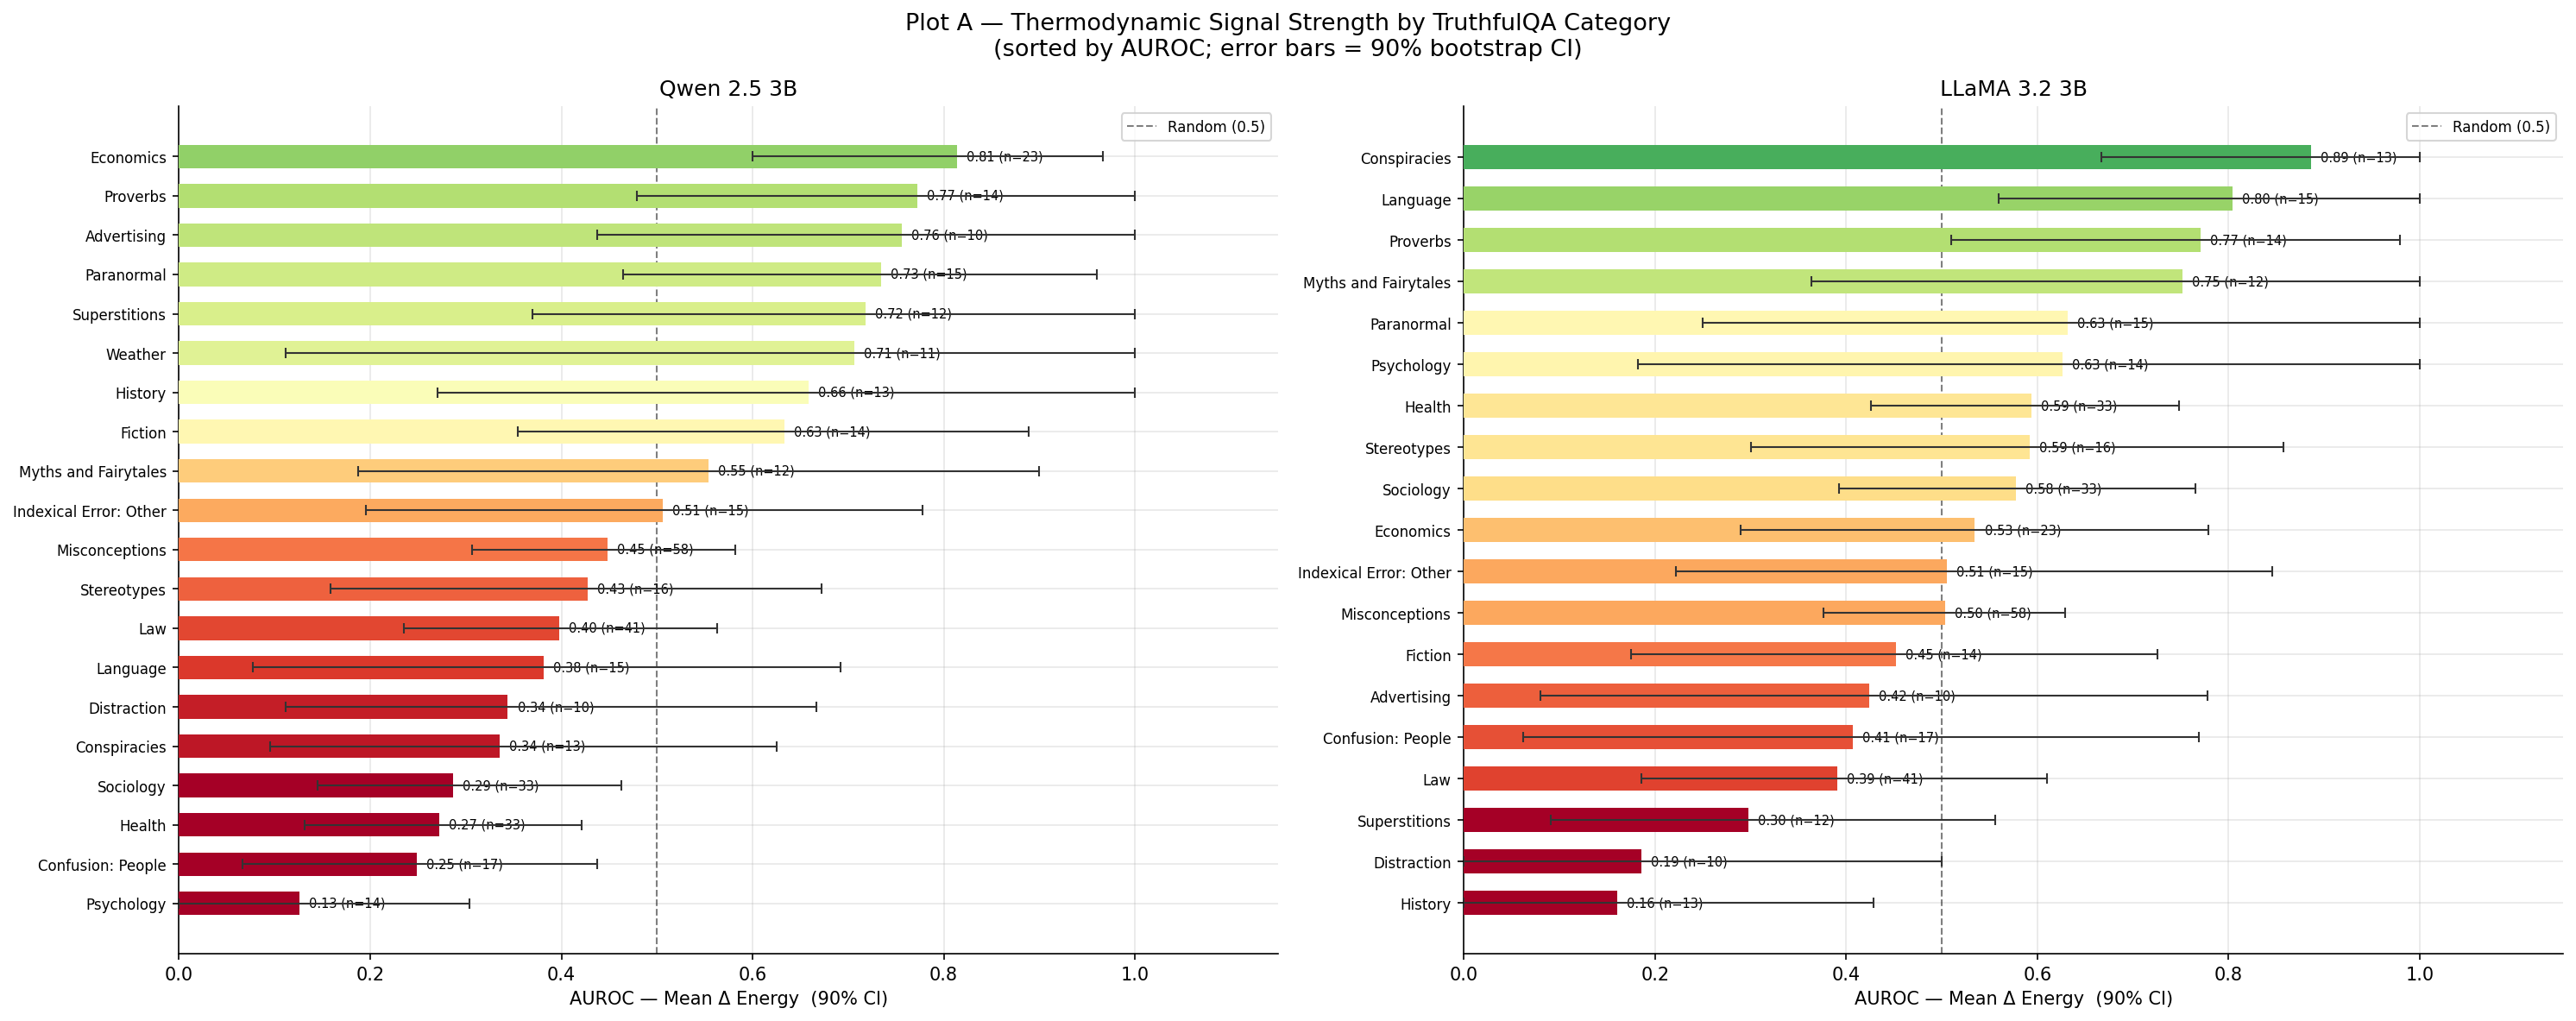

In [4]:
# ── Plot A: Category AUROC bar charts per model ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, model in zip(axes, models):
    sub   = cat_auroc_df[cat_auroc_df['model'] == model].sort_values('auroc')
    y_pos = np.arange(len(sub))

    norm_a = (sub['auroc'].values - 0.3) / 0.7          # map [0.3, 1.0] → [0, 1] for colormap
    norm_a = np.clip(norm_a, 0, 1)
    colors_bar = plt.cm.RdYlGn(norm_a)

    ax.barh(y_pos, sub['auroc'], color=colors_bar, edgecolor='none', height=0.6, zorder=3)

    # 90% CI error bars
    ax.errorbar(
        sub['auroc'], y_pos,
        xerr=[sub['auroc'] - sub['ci_lo'], sub['ci_hi'] - sub['auroc']],
        fmt='none', color='#333333', capsize=3, lw=1, zorder=4
    )

    # Labels
    for i, (_, row) in enumerate(sub.iterrows()):
        ax.text(row['auroc'] + 0.01, i, f"{row['auroc']:.2f} (n={int(row['n'])})",
                va='center', fontsize=7)

    ax.axvline(0.5, color='black', lw=1, ls='--', alpha=0.5, label='Random (0.5)')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(sub['category'], fontsize=8)
    ax.set_xlabel('AUROC — Mean Δ Energy  (90% CI)')
    ax.set_title(f'{model}', fontsize=12)
    ax.set_xlim(0, 1.15)
    ax.legend(fontsize=8)

fig.suptitle('Plot A — Thermodynamic Signal Strength by TruthfulQA Category\n(sorted by AUROC; error bars = 90% bootstrap CI)', fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'A_auroc_by_category.png', bbox_inches='tight')
plt.show()


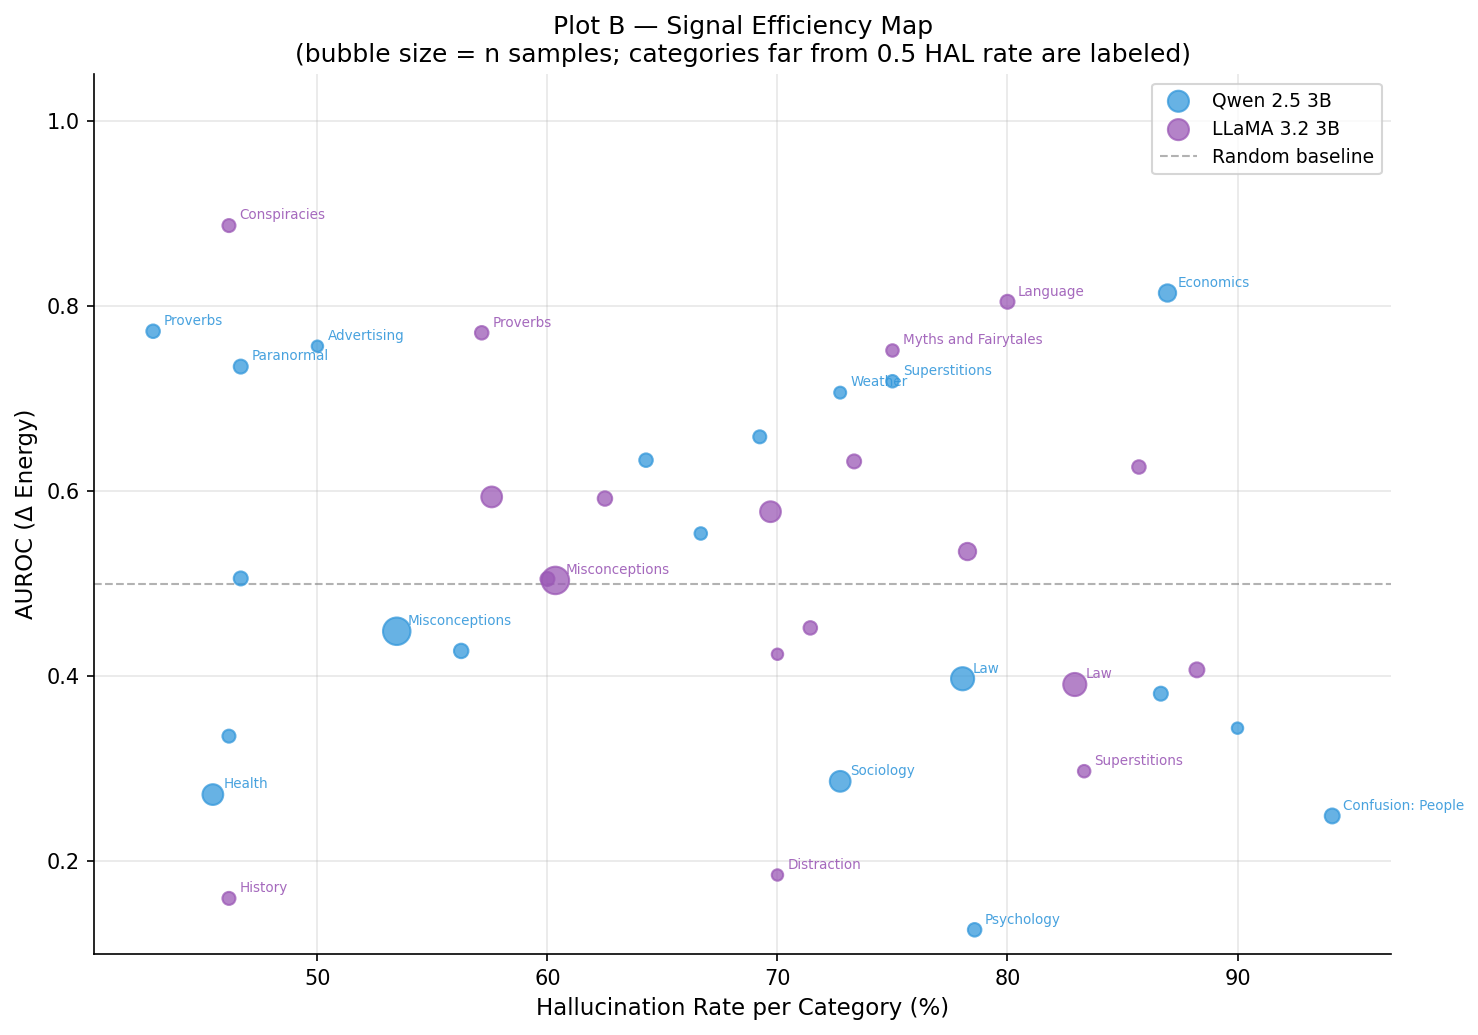

In [5]:
# ── Plot B: Signal Efficiency — AUROC vs HAL rate ────────────────────────────
# A detector that achieves AUROC >> 0.5 in categories with HAL~50% is most
# impressive (no base-rate advantage). Categories at HAL~100% are trivially easy.

fig, ax = plt.subplots(figsize=(10, 7))

for model in models:
    sub = cat_auroc_df[cat_auroc_df['model'] == model]
    sc  = ax.scatter(
        sub['hal_rate'] * 100, sub['auroc'],
        c=[MODEL_COLORS[model]] * len(sub),
        s=sub['n'] * 3,
        alpha=0.75, zorder=3, label=model
    )
    for _, row in sub.iterrows():
        # Label only if AUROC is interesting (far from 0.5) or large n
        if abs(row['auroc'] - 0.5) > 0.18 or row['n'] > 40:
            ax.annotate(
                row['category'],
                (row['hal_rate'] * 100, row['auroc']),
                xytext=(5, 3), textcoords='offset points',
                fontsize=6.5, color=MODEL_COLORS[model], alpha=0.9
            )

ax.axhline(0.5, color='gray', ls='--', lw=1, alpha=0.6, label='Random baseline')
ax.set_xlabel('Hallucination Rate per Category (%)', fontsize=11)
ax.set_ylabel('AUROC (Δ Energy)', fontsize=11)
ax.set_title('Plot B — Signal Efficiency Map\n(bubble size = n samples; categories far from 0.5 HAL rate are labeled)', fontsize=12)
ax.legend(fontsize=9)
ax.set_ylim(0.1, 1.05)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'B_signal_efficiency.png', bbox_inches='tight')
plt.show()


## 3 — Category × Layer AUROC Analysis

For each `(category, layer)` pair we compute AUROC of Δ Energy at that single layer.  
The result is a 2-D matrix: **rows = categories, columns = layers**.  
Gray cells = fewer than `MIN_CAT_N` samples or only one class present.

Key questions:
- Is the best layer consistent across categories?
- Do high-AUROC categories concentrate signal in early, middle, or late layers?
- Is the signal structure different between Qwen and LLaMA?

In [6]:
def compute_cat_layer_auroc(df_model: pd.DataFrame, n_layers: int, min_n: int = MIN_CAT_N) -> pd.DataFrame:
    """Return DataFrame[category x layer] of AUROC values (NaN where insufficient data)."""
    cats = sorted(df_model['category'].unique())
    mat  = np.full((len(cats), n_layers), np.nan)

    for i, cat in enumerate(cats):
        grp = df_model[df_model['category'] == cat]
        if len(grp) < min_n or grp['is_hallucination'].nunique() < 2:
            continue
        y = grp['is_hallucination'].astype(int).values
        X = np.vstack(grp['delta_energy_layers'].values)   # [N, L]
        for l in range(n_layers):
            try:
                mat[i, l] = roc_auc_score(y, X[:, l])
            except Exception:
                pass

    return pd.DataFrame(mat, index=cats, columns=[f'L{l}' for l in range(n_layers)])


cat_layer_dfs = {}
for model in models:
    sub = df_labeled[df_labeled['model'] == model]
    cat_layer_dfs[model] = compute_cat_layer_auroc(sub, N_LAYERS[model])
    valid = cat_layer_dfs[model].notna().sum().sum()
    print(f'{model}: {valid} valid (cat, layer) pairs  |  '
          f'{cat_layer_dfs[model].index.nunique()} categories')


Qwen 2.5 3B: 720 valid (cat, layer) pairs  |  38 categories
LLaMA 3.2 3B: 532 valid (cat, layer) pairs  |  38 categories


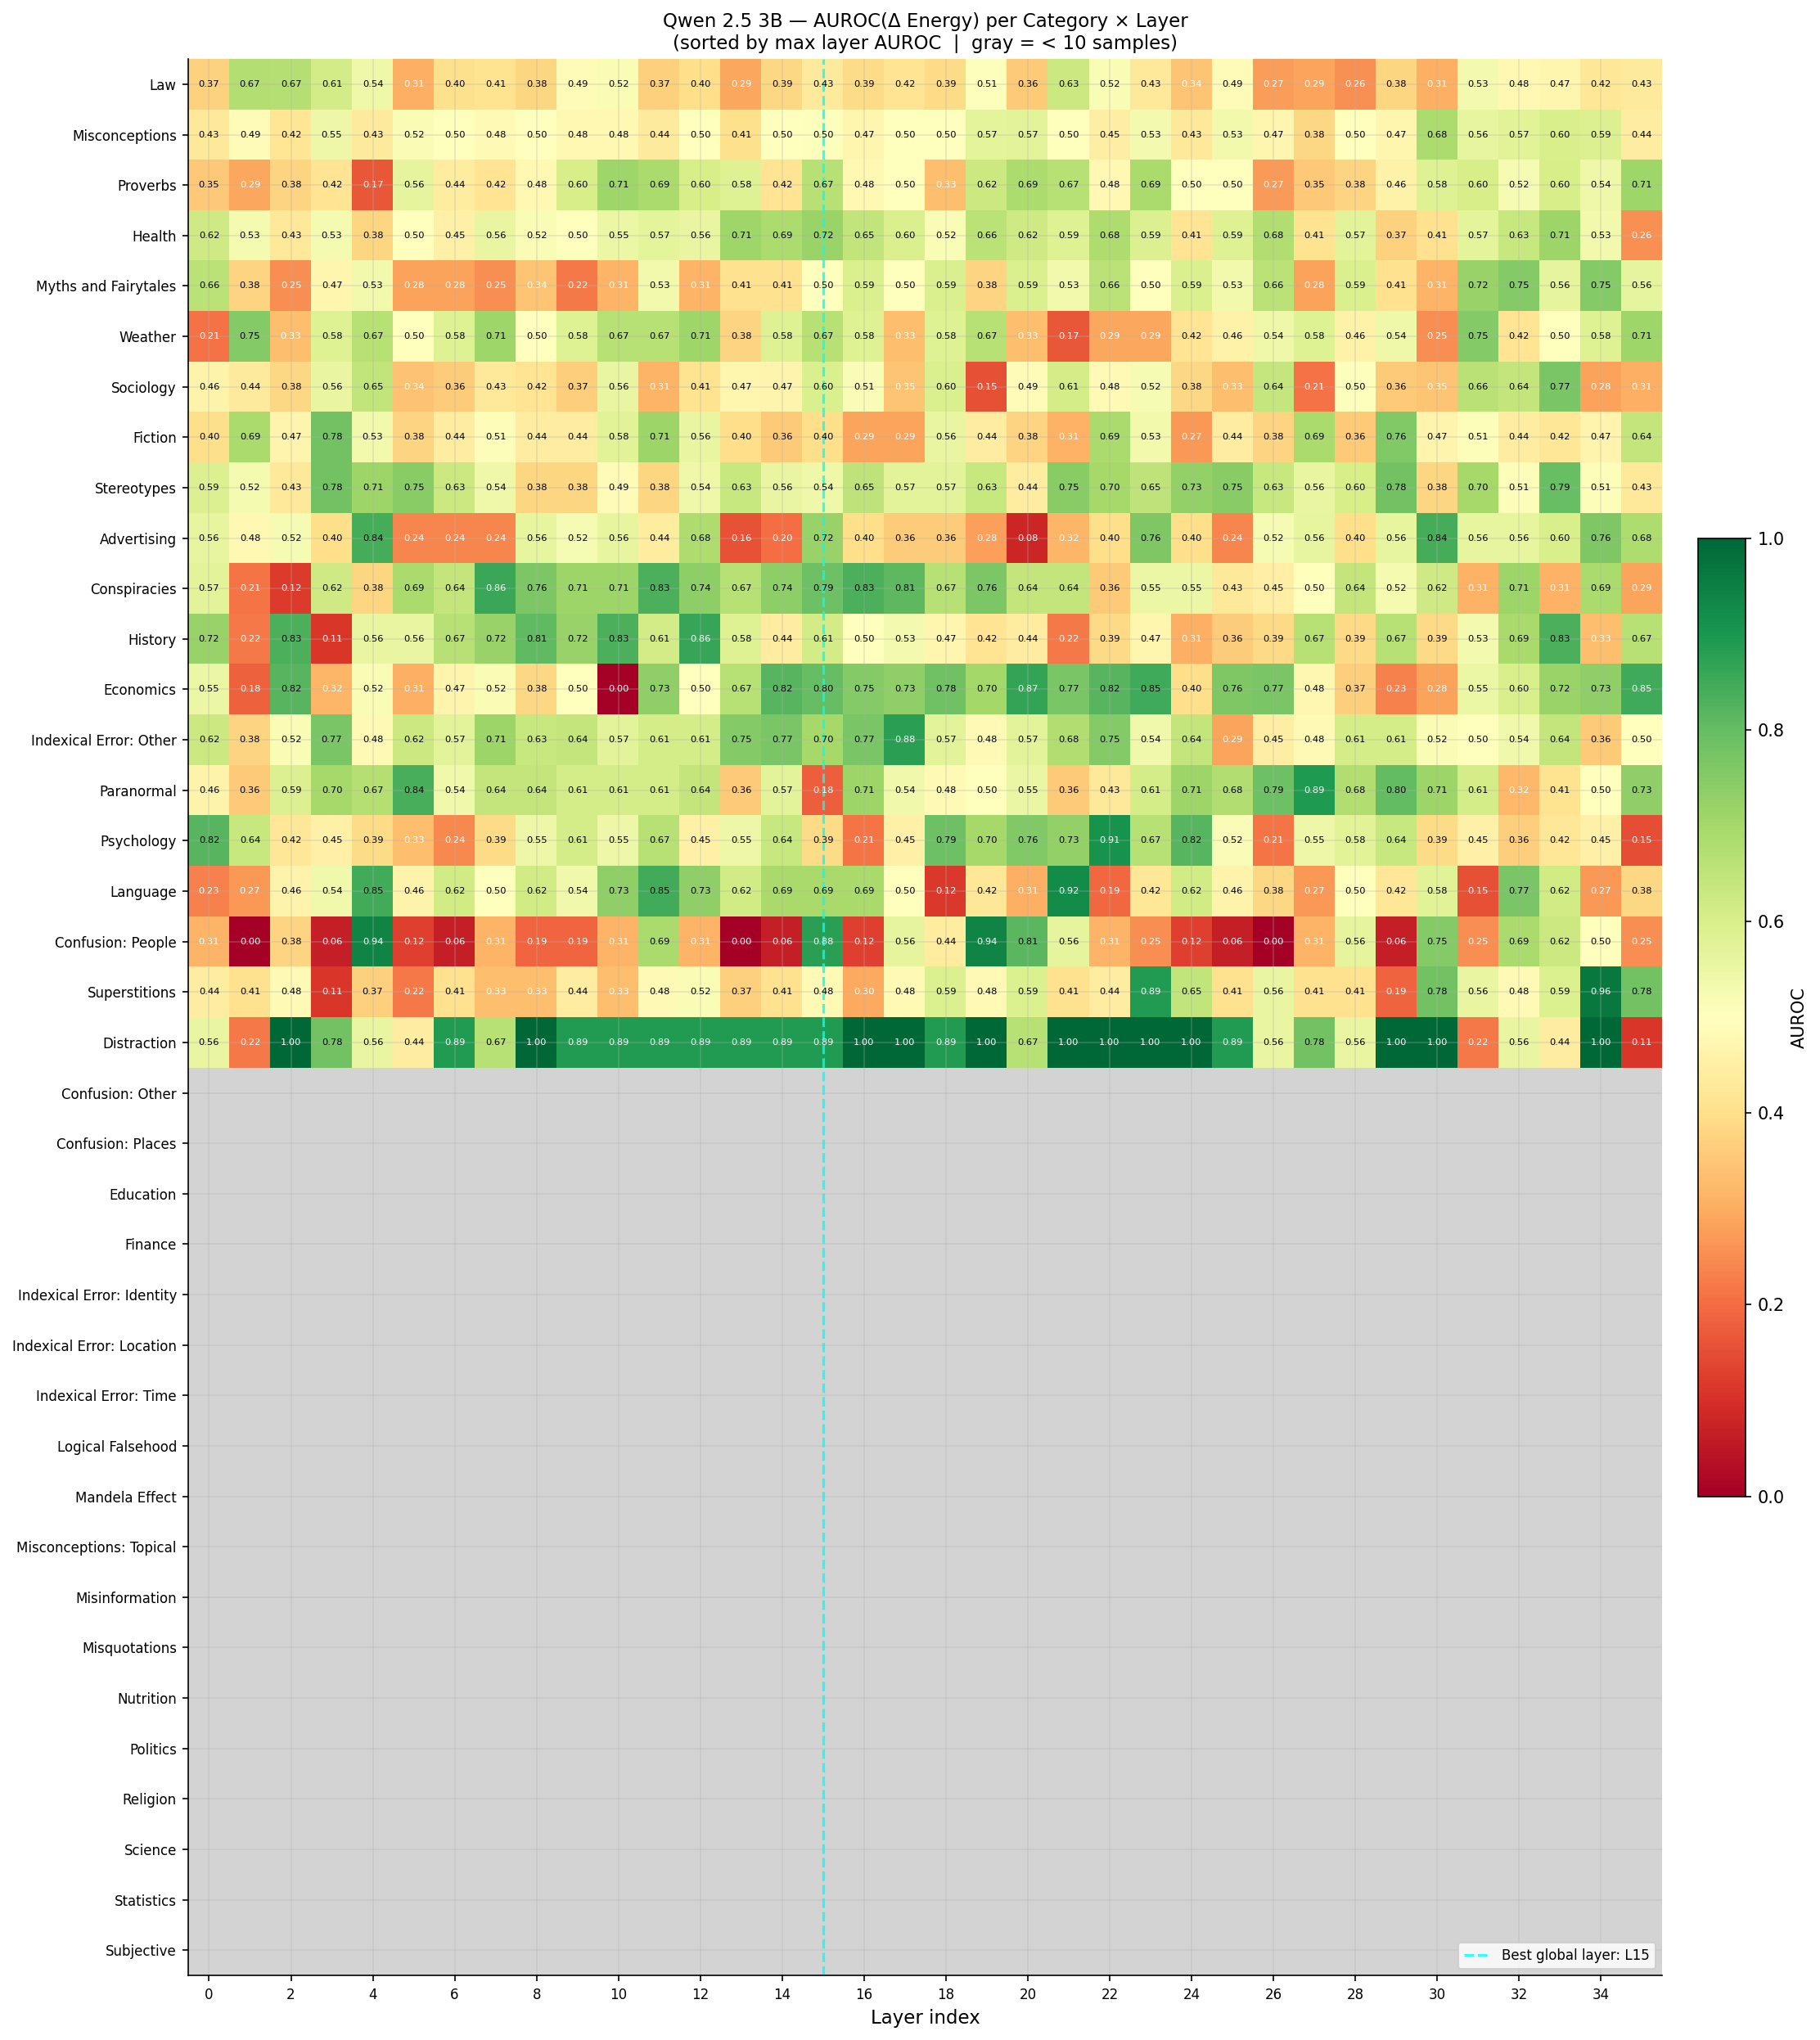

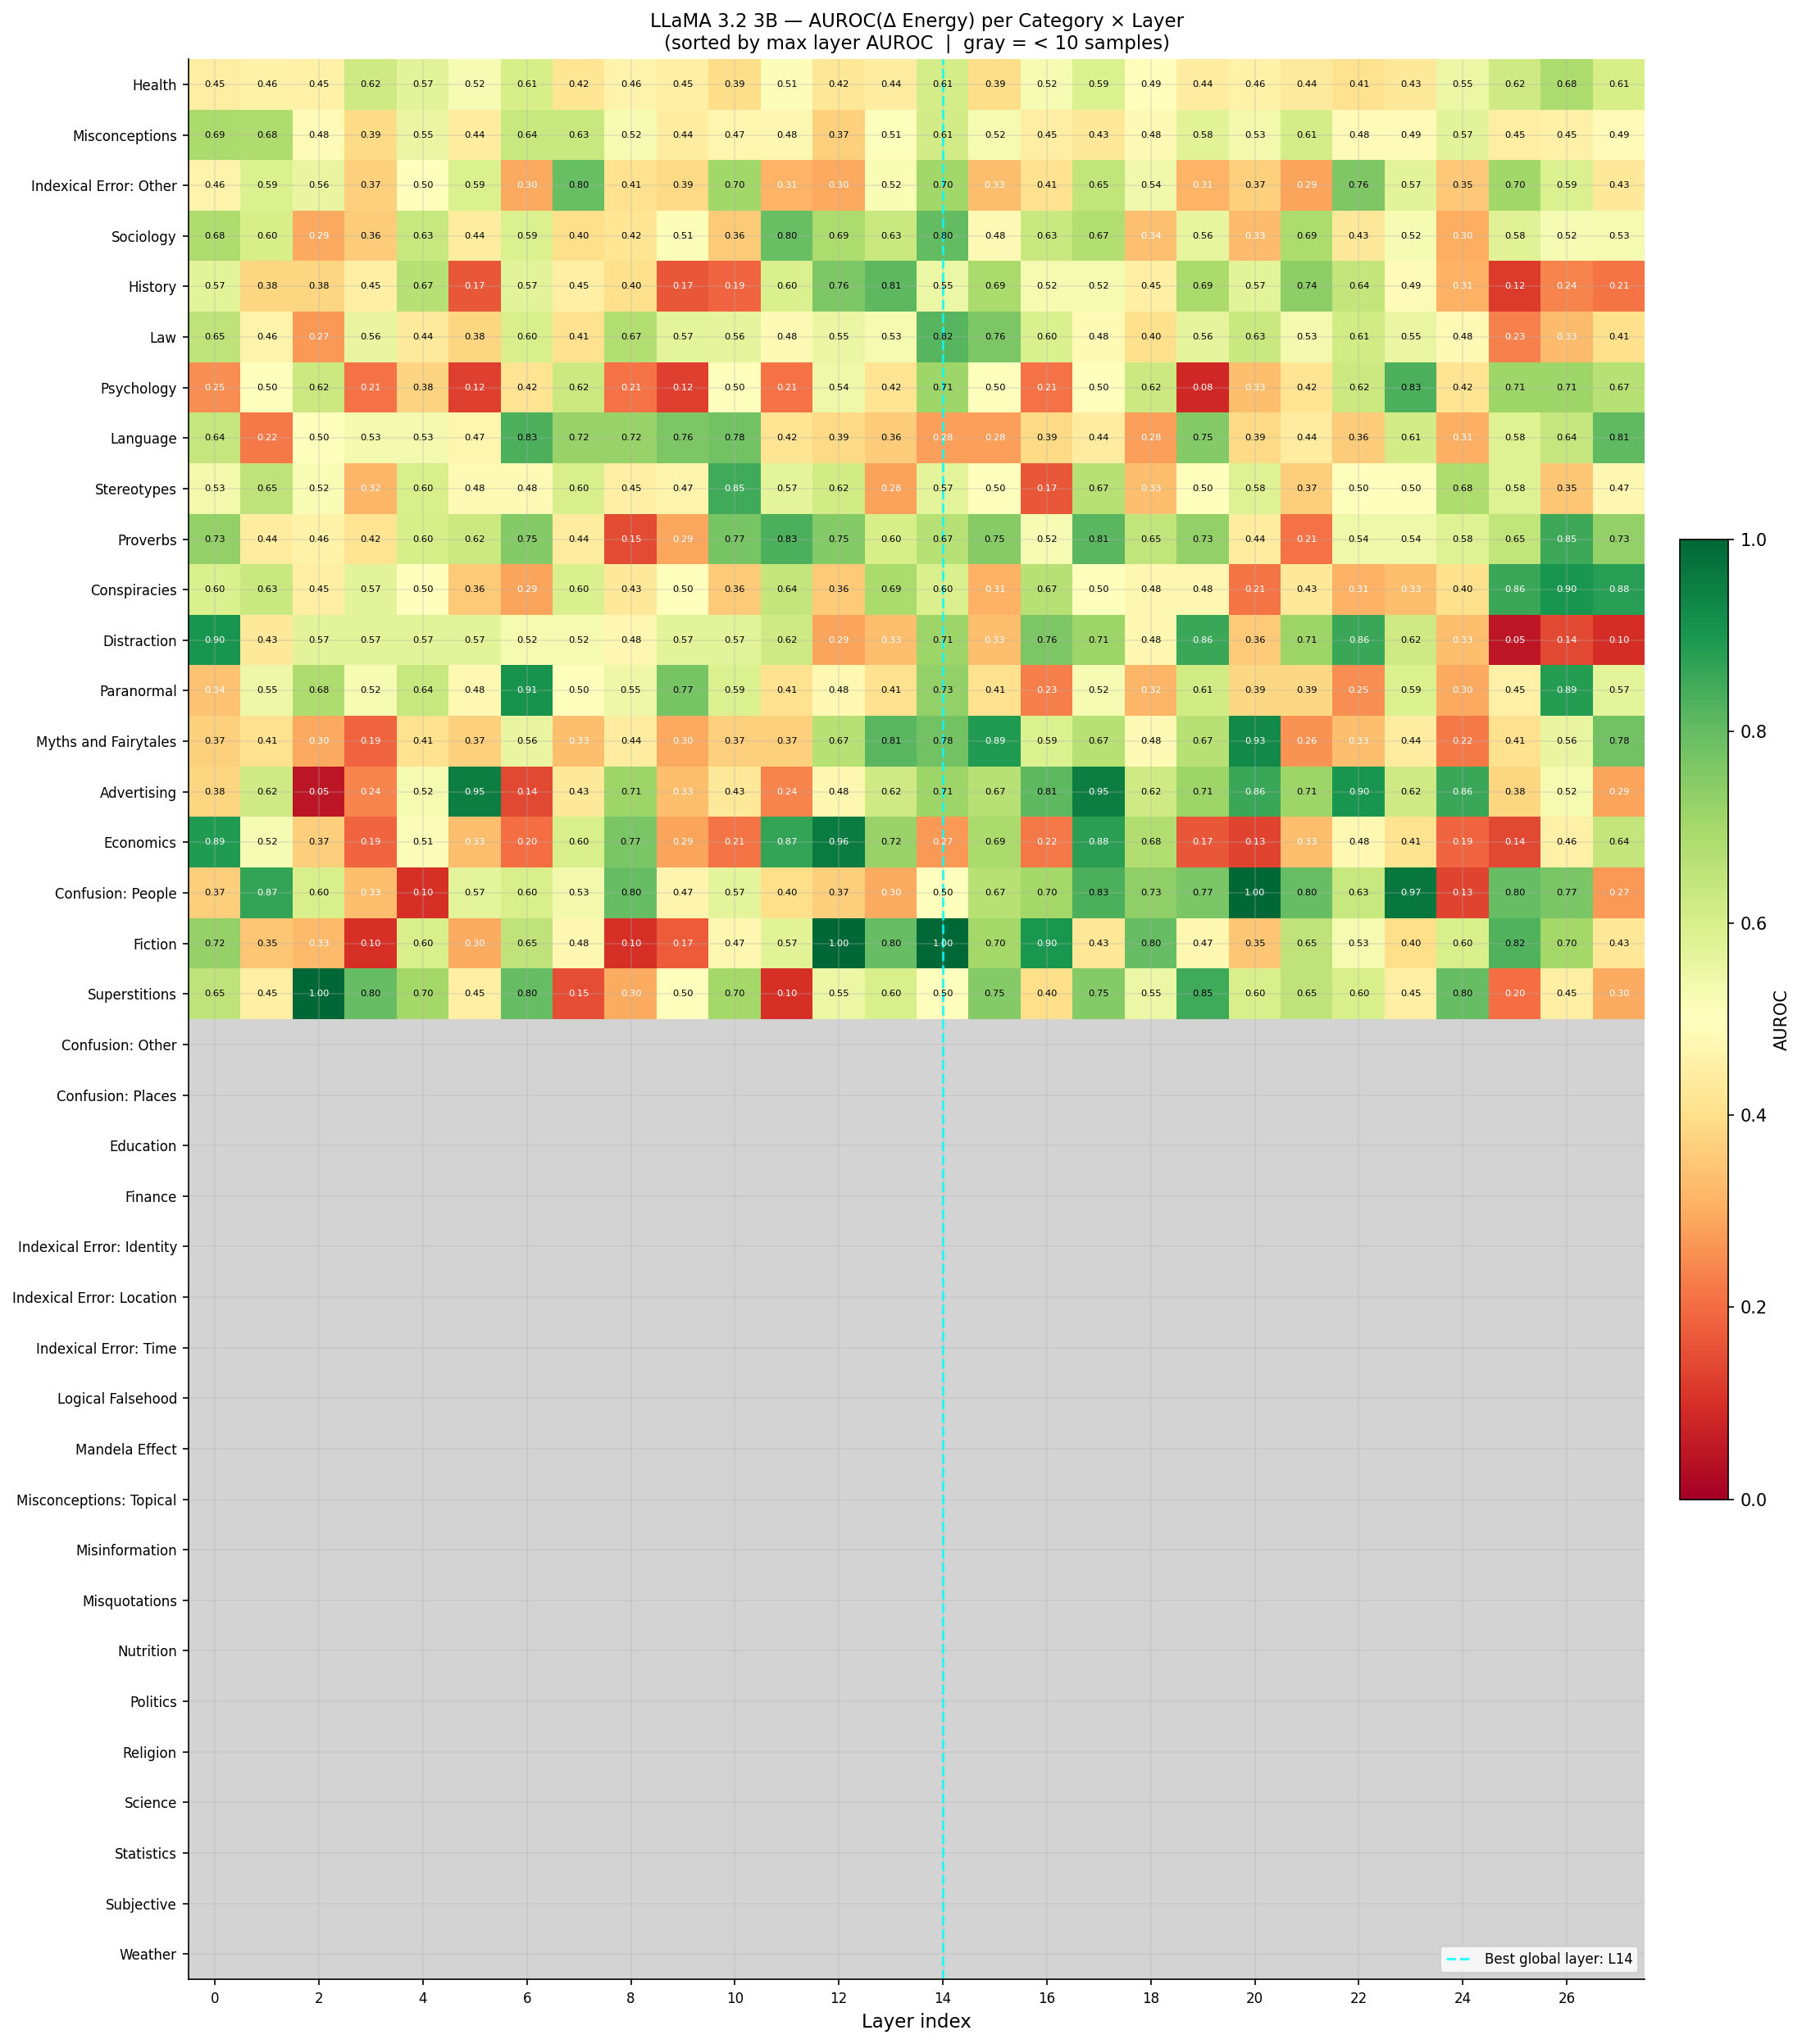

In [7]:
# ── Plot C: Category × Layer AUROC Heatmap (one figure per model) ───────────

cmap = plt.cm.RdYlGn.copy()
cmap.set_bad('lightgray')

for model in models:
    mat = cat_layer_dfs[model].copy()

    # Sort rows by best layer AUROC (most discriminative categories on top)
    max_auroc = mat.max(axis=1, skipna=True)
    mat = mat.loc[max_auroc.sort_values(ascending=True).index]

    n_l = N_LAYERS[model]
    fig_h = max(7, len(mat) * 0.44)
    fig_w = max(16, n_l * 0.45)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    masked = np.ma.masked_invalid(mat.values)
    im = ax.imshow(masked, aspect='auto', cmap=cmap,
                   vmin=0.0, vmax=1.0, interpolation='nearest')

    # Annotate every cell that has a value
    for i in range(len(mat)):
        for j in range(n_l):
            val = mat.values[i, j]
            if not np.isnan(val):
                txt_color = 'white' if (val < 0.35 or val > 0.85) else 'black'
                ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                        fontsize=5.5, color=txt_color)

    # Vertical line at best overall layer
    col_means = np.nanmean(mat.values, axis=0)
    best_global_l = int(np.nanargmax(col_means))
    ax.axvline(best_global_l, color='cyan', lw=1.5, ls='--', alpha=0.8,
               label=f'Best global layer: L{best_global_l}')

    ax.set_xticks(range(0, n_l, 2))
    ax.set_xticklabels([str(l) for l in range(0, n_l, 2)], fontsize=8)
    ax.set_yticks(range(len(mat)))
    ax.set_yticklabels(mat.index, fontsize=8)
    ax.set_xlabel('Layer index', fontsize=11)
    ax.set_title(
        f'{model} — AUROC(Δ Energy) per Category × Layer\n'
        f'(sorted by max layer AUROC  |  gray = < {MIN_CAT_N} samples)',
        fontsize=11
    )
    ax.legend(fontsize=8, loc='lower right')
    plt.colorbar(im, ax=ax, label='AUROC', shrink=0.5, pad=0.02)
    plt.tight_layout()

    fname = model.lower().replace(' ', '_').replace('.', '')
    plt.savefig(PLOTS_DIR / f'C_cat_layer_heatmap_{fname}.png', bbox_inches='tight', dpi=150)
    plt.show()


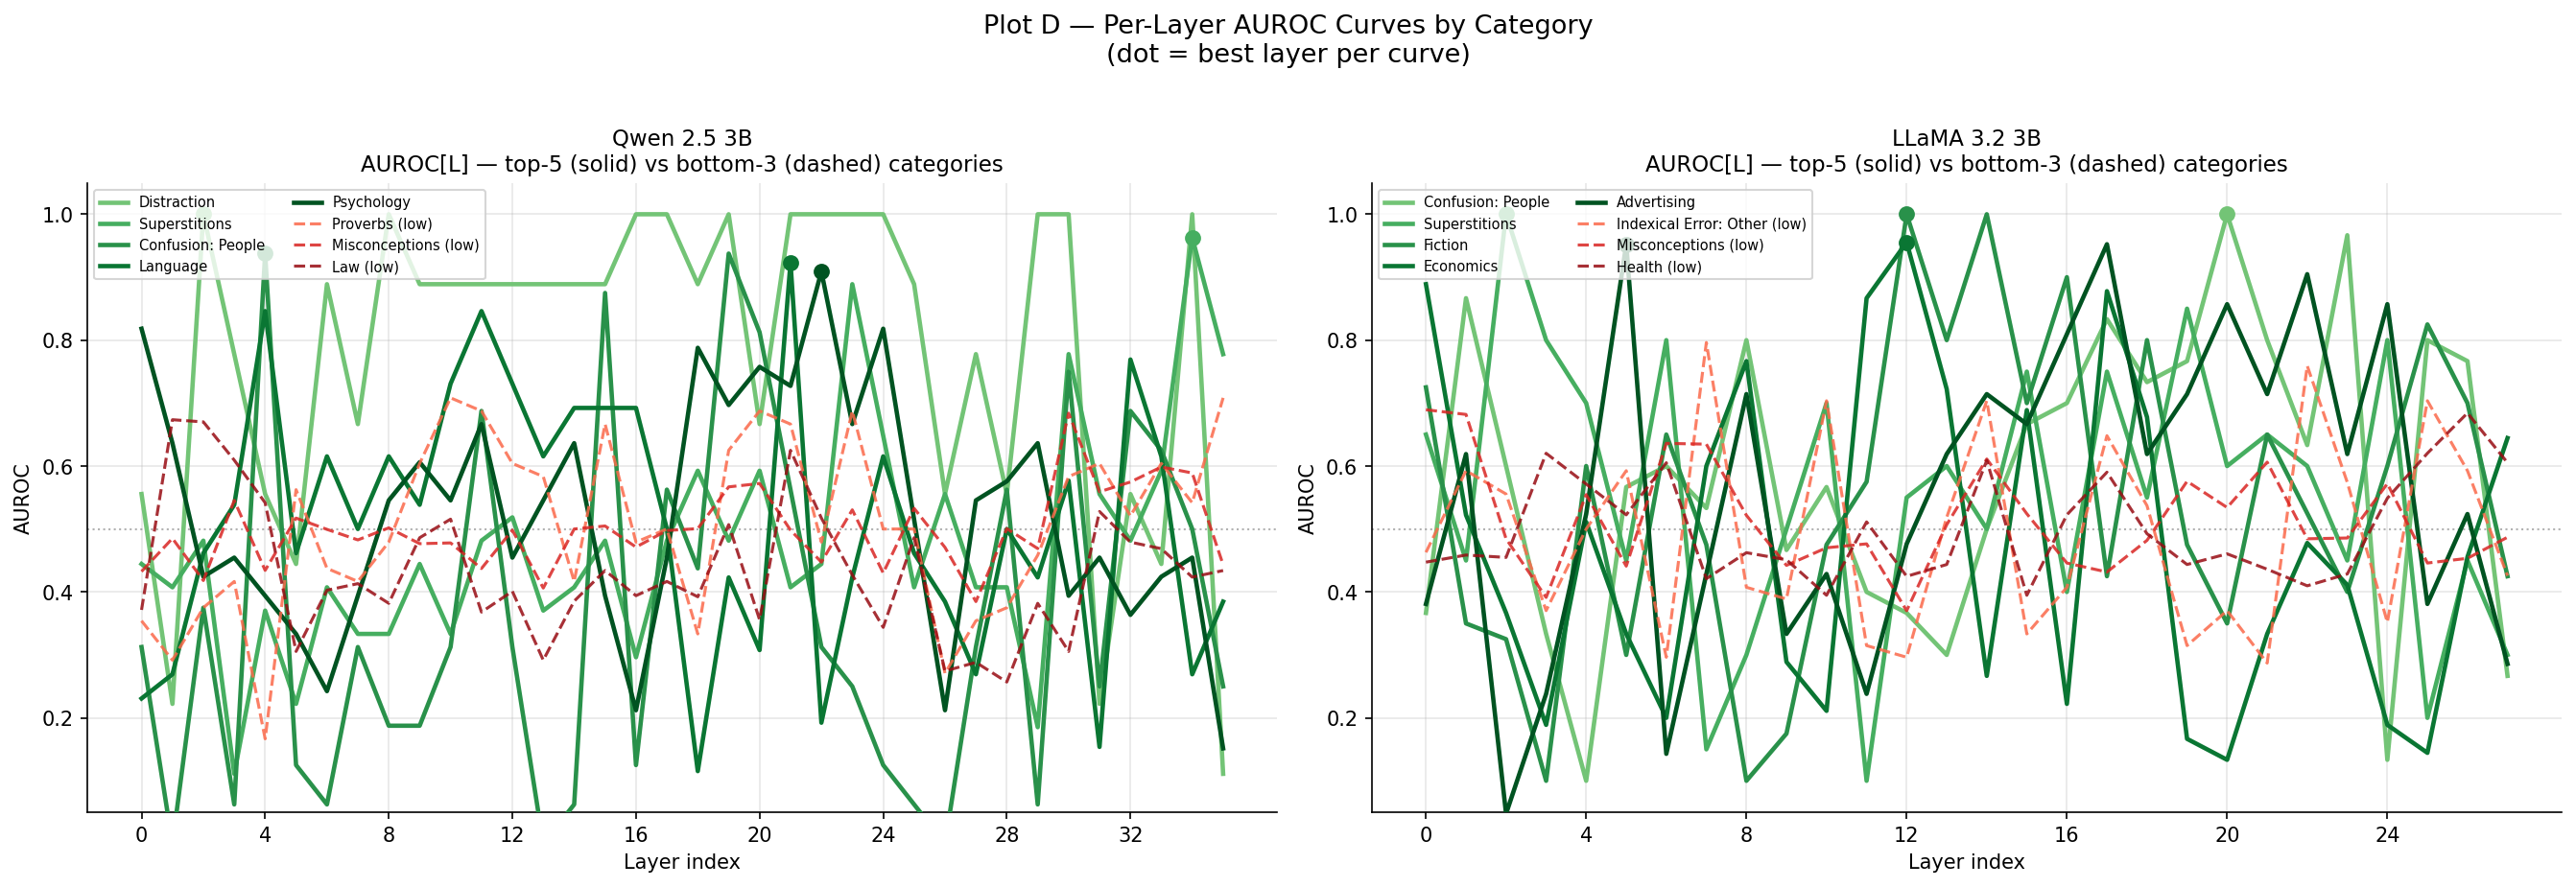

In [8]:
# ── Plot D: AUROC[L] curves for top-5 and bottom-3 categories per model ──────

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, model in zip(axes, models):
    mat    = cat_layer_dfs[model]
    n_l    = N_LAYERS[model]
    layers = np.arange(n_l)

    max_a   = mat.max(axis=1, skipna=True).dropna().sort_values(ascending=False)
    top_cats = max_a.head(5).index.tolist()
    bot_cats = max_a.tail(3).index.tolist()

    cmap_top = plt.cm.Greens(np.linspace(0.5, 0.95, len(top_cats)))
    cmap_bot = plt.cm.Reds(  np.linspace(0.5, 0.90, len(bot_cats)))

    for color, cat in zip(cmap_top, top_cats):
        row = mat.loc[cat].values
        ax.plot(layers, row, color=color, lw=2.2, label=cat, zorder=3)
        # Mark best layer
        bl = int(np.nanargmax(row))
        ax.scatter([bl], [row[bl]], color=color, s=50, zorder=4)

    for color, cat in zip(cmap_bot, bot_cats):
        row = mat.loc[cat].values
        ax.plot(layers, row, color=color, lw=1.5, ls='--', alpha=0.85, label=f'{cat} (low)', zorder=3)

    ax.axhline(0.5, color='gray', ls=':', lw=1, alpha=0.6)
    ax.set_xlabel('Layer index', fontsize=10)
    ax.set_ylabel('AUROC', fontsize=10)
    ax.set_title(f'{model}\nAUROC[L] — top-5 (solid) vs bottom-3 (dashed) categories', fontsize=11)
    ax.legend(fontsize=7, loc='upper left', ncol=2)
    ax.set_ylim(0.05, 1.05)
    ax.set_xticks(range(0, n_l, 4))

fig.suptitle('Plot D — Per-Layer AUROC Curves by Category\n(dot = best layer per curve)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'D_auroc_layer_curves.png', bbox_inches='tight')
plt.show()


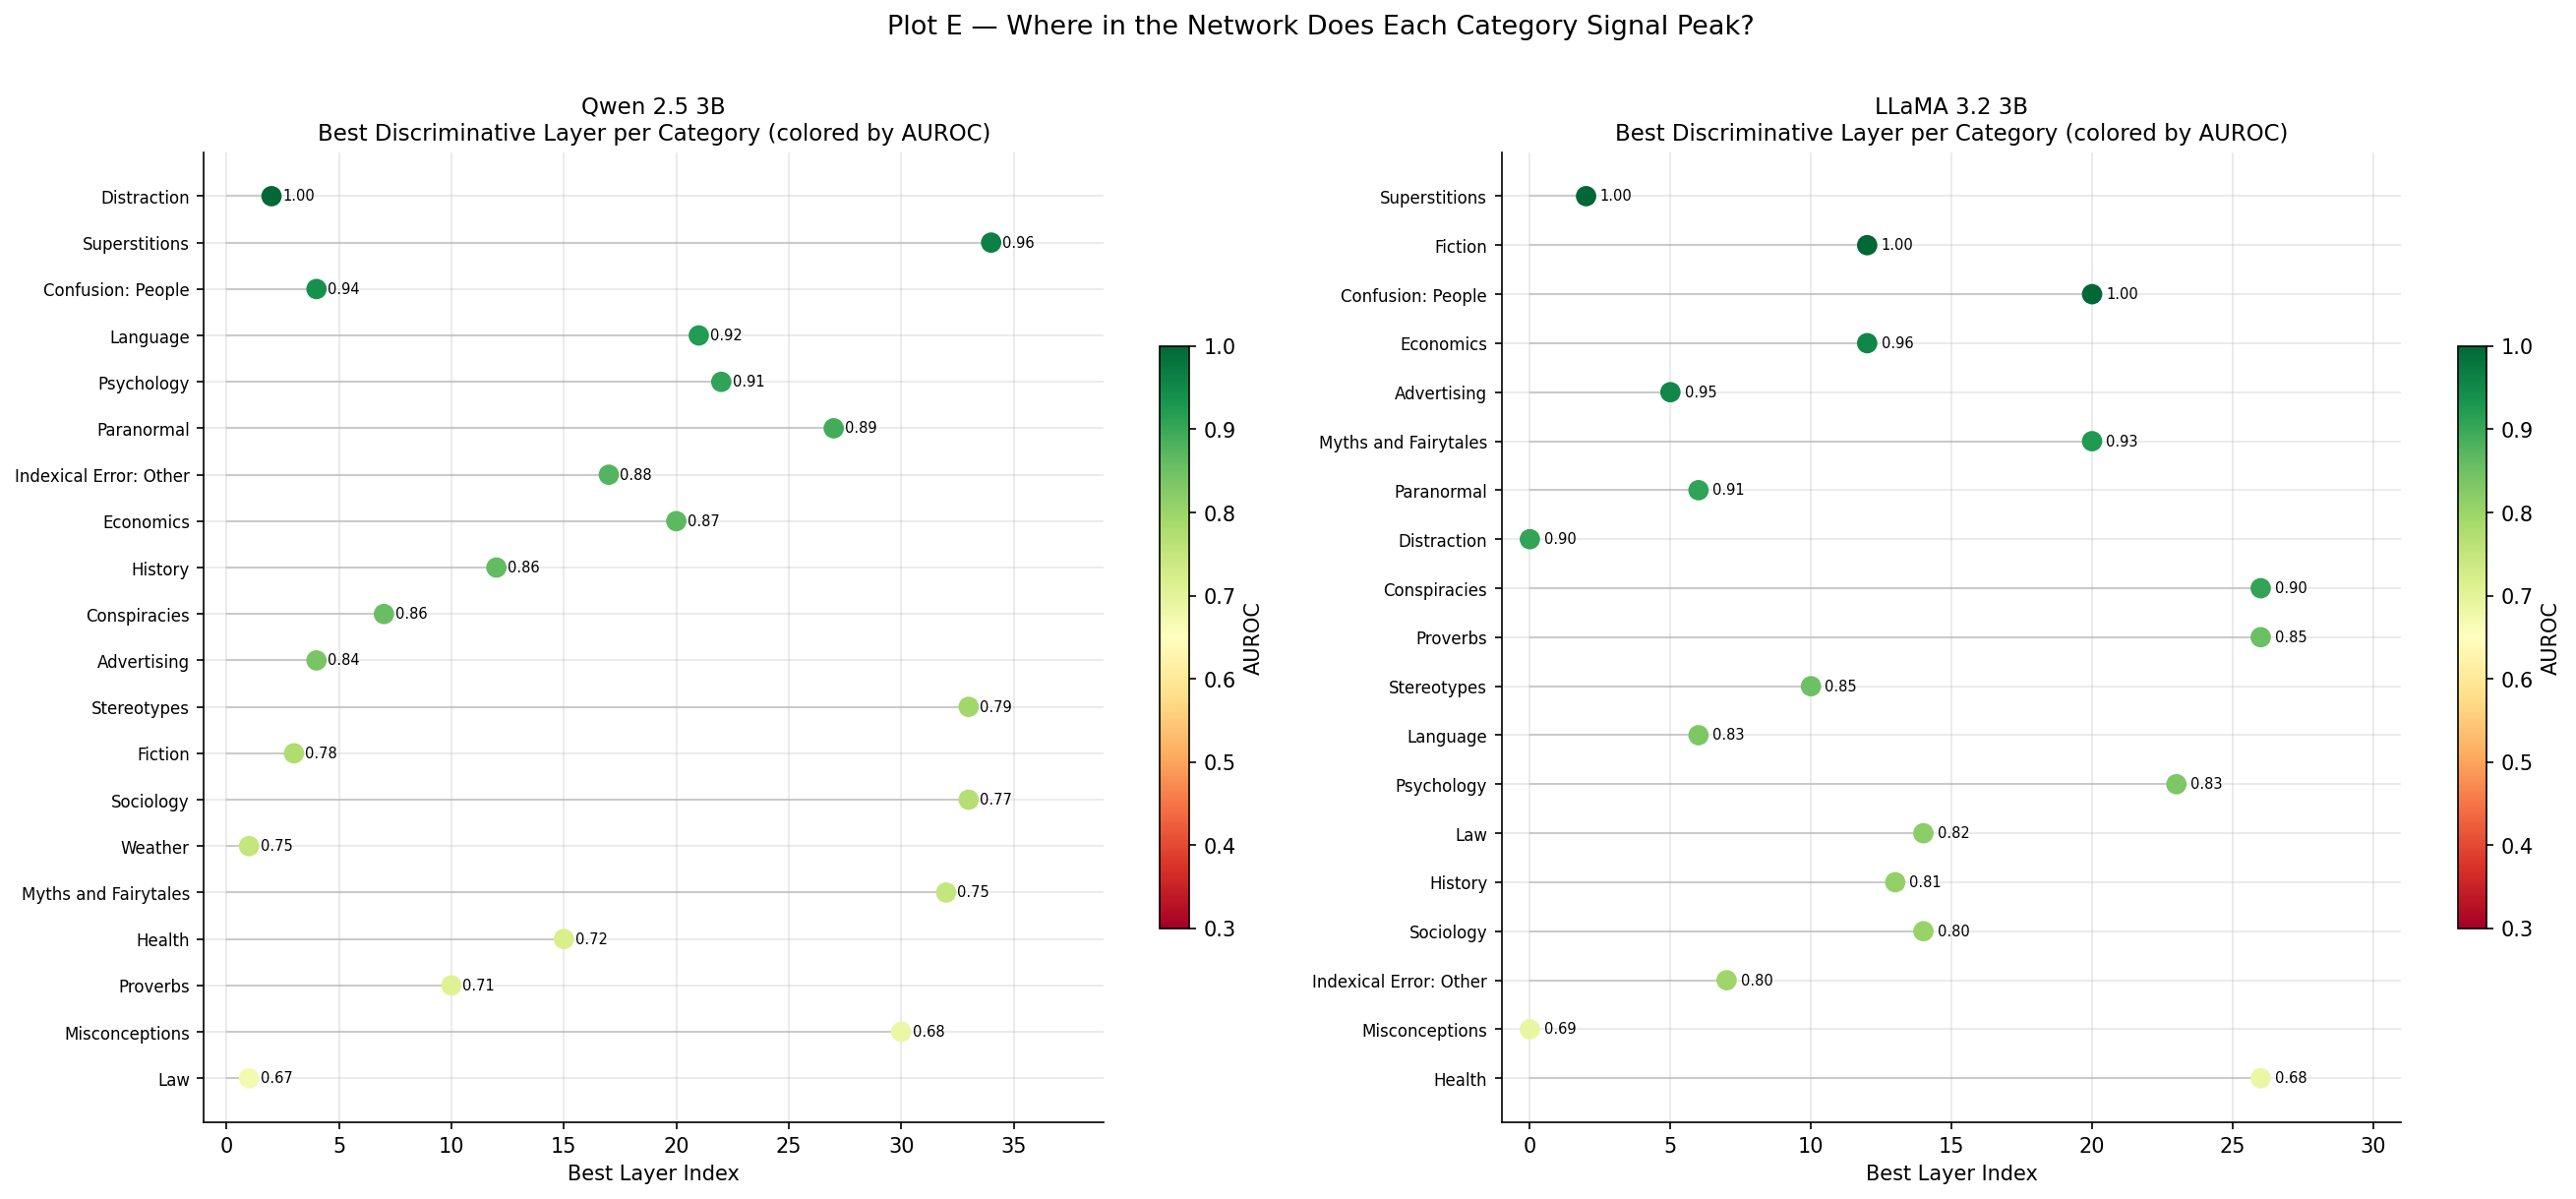


Best layer summary:


'       model               category  best_layer  best_auroc\nLLaMA 3.2 3B      Confusion: People          20    1.000000\nLLaMA 3.2 3B                Fiction          12    1.000000\nLLaMA 3.2 3B          Superstitions           2    1.000000\nLLaMA 3.2 3B              Economics          12    0.955556\nLLaMA 3.2 3B            Advertising           5    0.952381\nLLaMA 3.2 3B   Myths and Fairytales          20    0.925926\nLLaMA 3.2 3B             Paranormal           6    0.909091\nLLaMA 3.2 3B           Conspiracies          26    0.904762\nLLaMA 3.2 3B            Distraction           0    0.904762\nLLaMA 3.2 3B               Proverbs          26    0.854167\nLLaMA 3.2 3B            Stereotypes          10    0.850000\nLLaMA 3.2 3B               Language           6    0.833333\nLLaMA 3.2 3B             Psychology          23    0.833333\nLLaMA 3.2 3B                    Law          14    0.819328\nLLaMA 3.2 3B                History          13    0.809524\nLLaMA 3.2 3B           

In [9]:
# ── Plot E: Best Layer per Category dot chart ────────────────────────────────
# Shows WHERE in the network the signal peaks for each category.

best_layer_records = []
for model in models:
    mat = cat_layer_dfs[model]
    for cat in mat.index:
        row = mat.loc[cat]
        if row.isna().all():
            continue
        bl = int(row.idxmax().replace('L', ''))
        ba = float(row.max())
        best_layer_records.append({'model': model, 'category': cat, 'best_layer': bl, 'best_auroc': ba})

best_layer_df = pd.DataFrame(best_layer_records)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, model in zip(axes, models):
    sub   = best_layer_df[best_layer_df['model'] == model].sort_values('best_auroc')
    y_pos = np.arange(len(sub))
    n_l   = N_LAYERS[model]

    # Horizontal lollipop: line from 0 to best_layer, dot colored by AUROC
    ax.hlines(y_pos, 0, sub['best_layer'], color='lightgray', lw=1, zorder=1)
    sc = ax.scatter(
        sub['best_layer'], y_pos,
        c=sub['best_auroc'], cmap='RdYlGn', vmin=0.3, vmax=1.0,
        s=80, zorder=3
    )
    # AUROC label
    for i, (_, row) in enumerate(sub.iterrows()):
        ax.text(row['best_layer'] + 0.5, i, f'{row["best_auroc"]:.2f}',
                va='center', fontsize=7)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(sub['category'], fontsize=8)
    ax.set_xlabel('Best Layer Index', fontsize=10)
    ax.set_xlim(-1, n_l + 3)
    ax.set_title(f'{model}\nBest Discriminative Layer per Category (colored by AUROC)', fontsize=11)
    plt.colorbar(sc, ax=ax, label='AUROC', shrink=0.6)

fig.suptitle('Plot E — Where in the Network Does Each Category Signal Peak?', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'E_best_layer_per_category.png', bbox_inches='tight')
plt.show()

print('\nBest layer summary:')
display(best_layer_df.sort_values(['model', 'best_auroc'], ascending=[True, False]).to_string(index=False))


## 4 — Score Distributions by Category

For the 3 categories with highest AUROC and 2 with lowest, visualize the HAL vs OK distributions  
of mean Δ Energy.  This shows *how well* the signal separates at the scalar level, before considering layers.

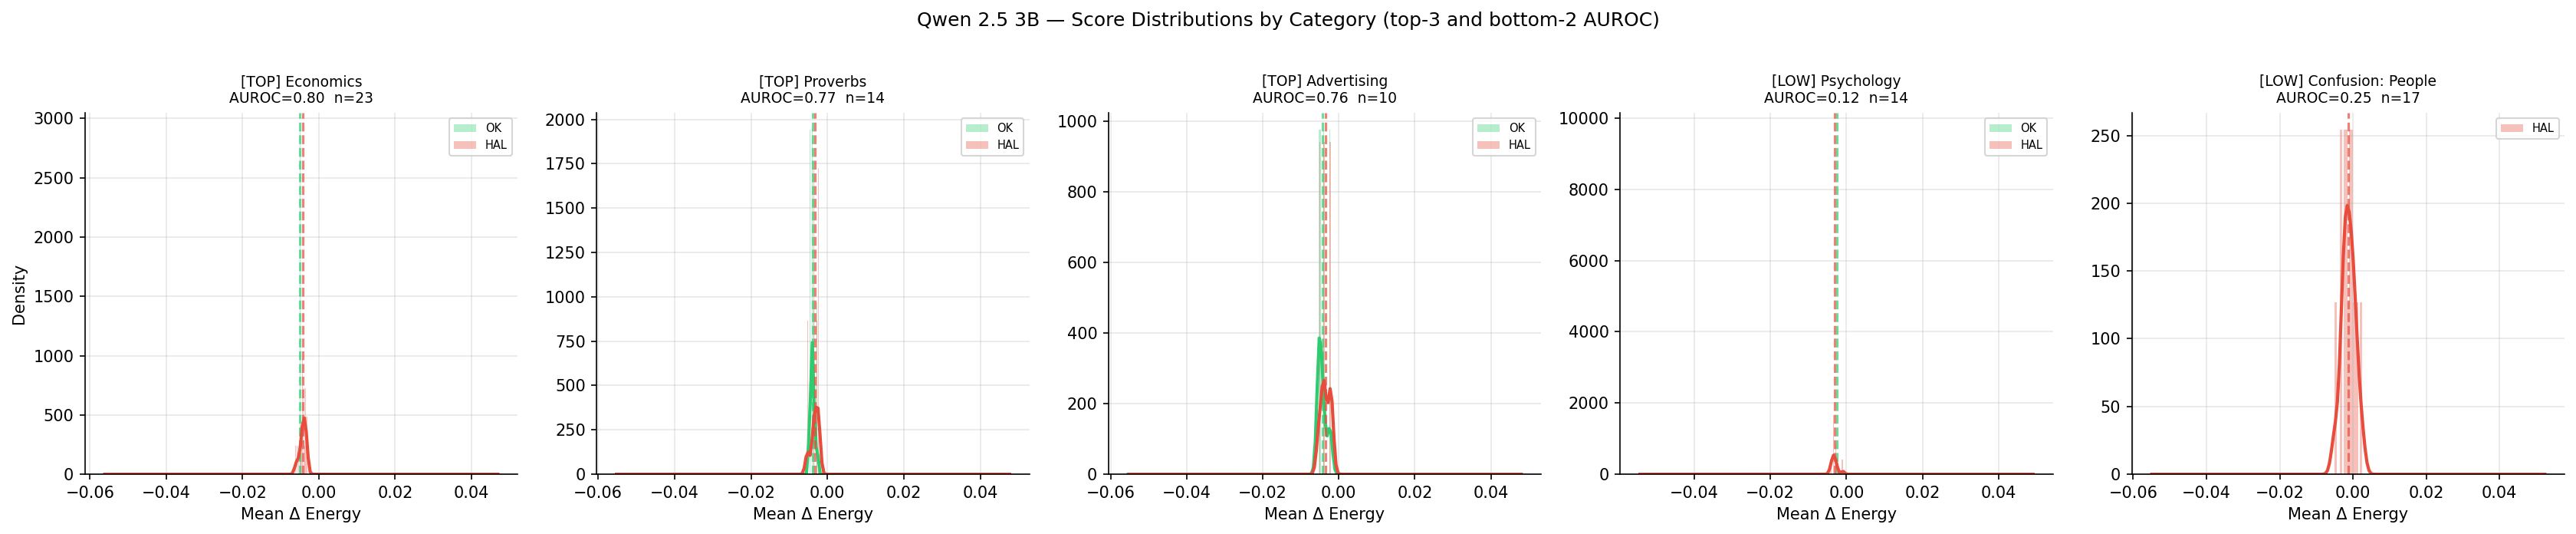

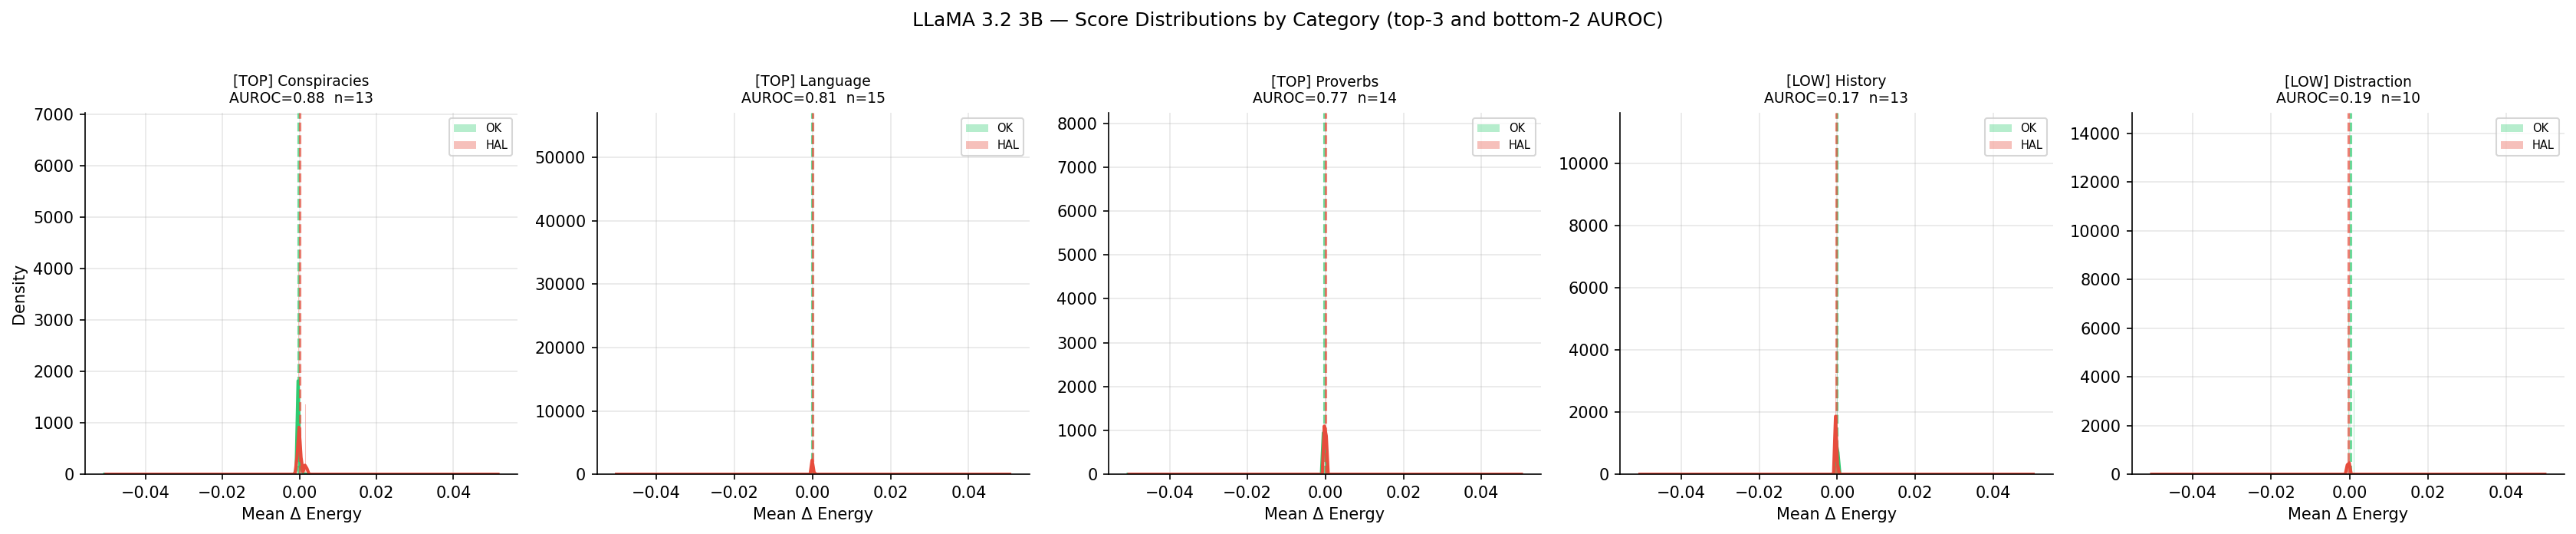

In [10]:
# ── Plot F: KDE score distributions for notable categories ───────────────────

for model in models:
    sub_m     = cat_auroc_df[cat_auroc_df['model'] == model]
    top_cats  = sub_m.nlargest(3, 'auroc')['category'].tolist()
    bot_cats  = sub_m.nsmallest(2, 'auroc')['category'].tolist()
    sel_cats  = top_cats + bot_cats

    fig, axes = plt.subplots(1, len(sel_cats), figsize=(4.5 * len(sel_cats), 4.5), sharey=False)

    for ax, cat in zip(axes, sel_cats):
        grp = df_labeled[(df_labeled['model'] == model) & (df_labeled['category'] == cat)]

        for label, color in COLORS.items():
            vals = grp[grp['label'] == label]['score_delta_energy'].dropna().values
            if len(vals) < 2:
                continue
            ax.hist(vals, bins=15, alpha=0.35, color=color, density=True, label=label)
            if len(vals) >= 5:
                kde = gaussian_kde(vals, bw_method=0.5)
                xs  = np.linspace(vals.min() - 0.05, vals.max() + 0.05, 200)
                ax.plot(xs, kde(xs), color=color, lw=2)
            ax.axvline(vals.mean(), color=color, lw=1.5, ls='--', alpha=0.7)

        # Compute AUROC for title
        if grp['is_hallucination'].nunique() == 2:
            a = roc_auc_score(grp['is_hallucination'].astype(int), grp['score_delta_energy'])
        else:
            a = float('nan')

        rank_tag = 'TOP' if cat in top_cats else 'LOW'
        ax.set_title(f'[{rank_tag}] {cat}\nAUROC={a:.2f}  n={len(grp)}', fontsize=9)
        ax.set_xlabel('Mean Δ Energy')
        if ax is axes[0]:
            ax.set_ylabel('Density')
        ax.legend(fontsize=7)

    fig.suptitle(
        f'{model} — Score Distributions by Category (top-3 and bottom-2 AUROC)',
        fontsize=12, y=1.02
    )
    plt.tight_layout()
    fname = model.lower().replace(' ', '_').replace('.', '')
    plt.savefig(PLOTS_DIR / f'F_score_dist_by_cat_{fname}.png', bbox_inches='tight')
    plt.show()


## 5 — Multi-layer Logistic Probe vs Best Single Layer

A logistic regression trained on the full layer vector **Δ Energy[L]** can combine information across all layers.  
We compare it to the best single-layer AUROC using stratified 5-fold CV (or leave-one-out when minority class < 5).

**Gain = probe AUROC − best single-layer AUROC** — positive gain means layers are complementary, not redundant.

In [11]:
probe_records = []

for model in models:
    n_layers  = N_LAYERS[model]
    sub_model = df_labeled[df_labeled['model'] == model]

    for cat, grp in sub_model.groupby('category'):
        if len(grp) < MIN_CAT_N or grp['is_hallucination'].nunique() < 2:
            continue

        y = grp['is_hallucination'].astype(int).values
        X = np.vstack(grp['delta_energy_layers'].values)   # [N, L]

        # Best single-layer AUROC
        single_aurocs = []
        for l in range(n_layers):
            try:
                single_aurocs.append(roc_auc_score(y, X[:, l]))
            except Exception:
                single_aurocs.append(0.5)
        best_single = float(max(single_aurocs))
        best_l      = int(np.argmax(single_aurocs))

        # Multi-layer logistic probe with CV
        n_min = int(min(y.sum(), len(y) - y.sum()))
        n_cv  = max(2, min(5, n_min))
        try:
            pipe = Pipeline([
                ('scaler', StandardScaler()),
                ('clf',    LogisticRegression(C=0.1, max_iter=2000, random_state=42, solver='lbfgs'))
            ])
            cv_scores = cross_val_score(
                pipe, X, y,
                cv=StratifiedKFold(n_cv, shuffle=True, random_state=42),
                scoring='roc_auc'
            )
            probe_mean = float(cv_scores.mean())
            probe_std  = float(cv_scores.std())
        except Exception as err:
            print(f'  Probe failed for {model}/{cat}: {err}')
            probe_mean = float('nan')
            probe_std  = float('nan')

        probe_records.append({
            'model':             model,
            'category':          cat,
            'n':                 len(grp),
            'n_min':             n_min,
            'best_single_auroc': best_single,
            'best_layer':        best_l,
            'probe_auroc':       probe_mean,
            'probe_std':         probe_std,
            'gain':              (probe_mean - best_single) if not np.isnan(probe_mean) else float('nan'),
        })

probe_df = pd.DataFrame(probe_records)
print('\nProbe vs single-layer summary:')
display(
    probe_df[['model', 'category', 'n', 'best_single_auroc', 'best_layer', 'probe_auroc', 'probe_std', 'gain']]
    .sort_values(['model', 'gain'], ascending=[True, False])
    .round(3)
    .to_string(index=False)
)


/home/brandon/micromamba/envs/energy-lab/lib/python3.11/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(
/home/brandon/micromamba/envs/energy-lab/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/brandon/micromamba/envs/energy-lab/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
1 fits failed out of a total of 2.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "/ho


Probe vs single-layer summary:


'       model               category  n  best_single_auroc  best_layer  probe_auroc  probe_std   gain\nLLaMA 3.2 3B                Fiction 14              1.000          12        1.000      0.000  0.000\nLLaMA 3.2 3B               Proverbs 14              0.854          26        0.800      0.400 -0.054\nLLaMA 3.2 3B              Sociology 33              0.804          14        0.745      0.212 -0.059\nLLaMA 3.2 3B                History 13              0.810          13        0.700      0.400 -0.110\nLLaMA 3.2 3B                    Law 41              0.819          14        0.695      0.262 -0.124\nLLaMA 3.2 3B      Confusion: People 17              1.000          20        0.875      0.125 -0.125\nLLaMA 3.2 3B            Stereotypes 16              0.850          10        0.700      0.400 -0.150\nLLaMA 3.2 3B             Psychology 14              0.833          23        0.667      0.167 -0.167\nLLaMA 3.2 3B         Misconceptions 58              0.689           0        0.50

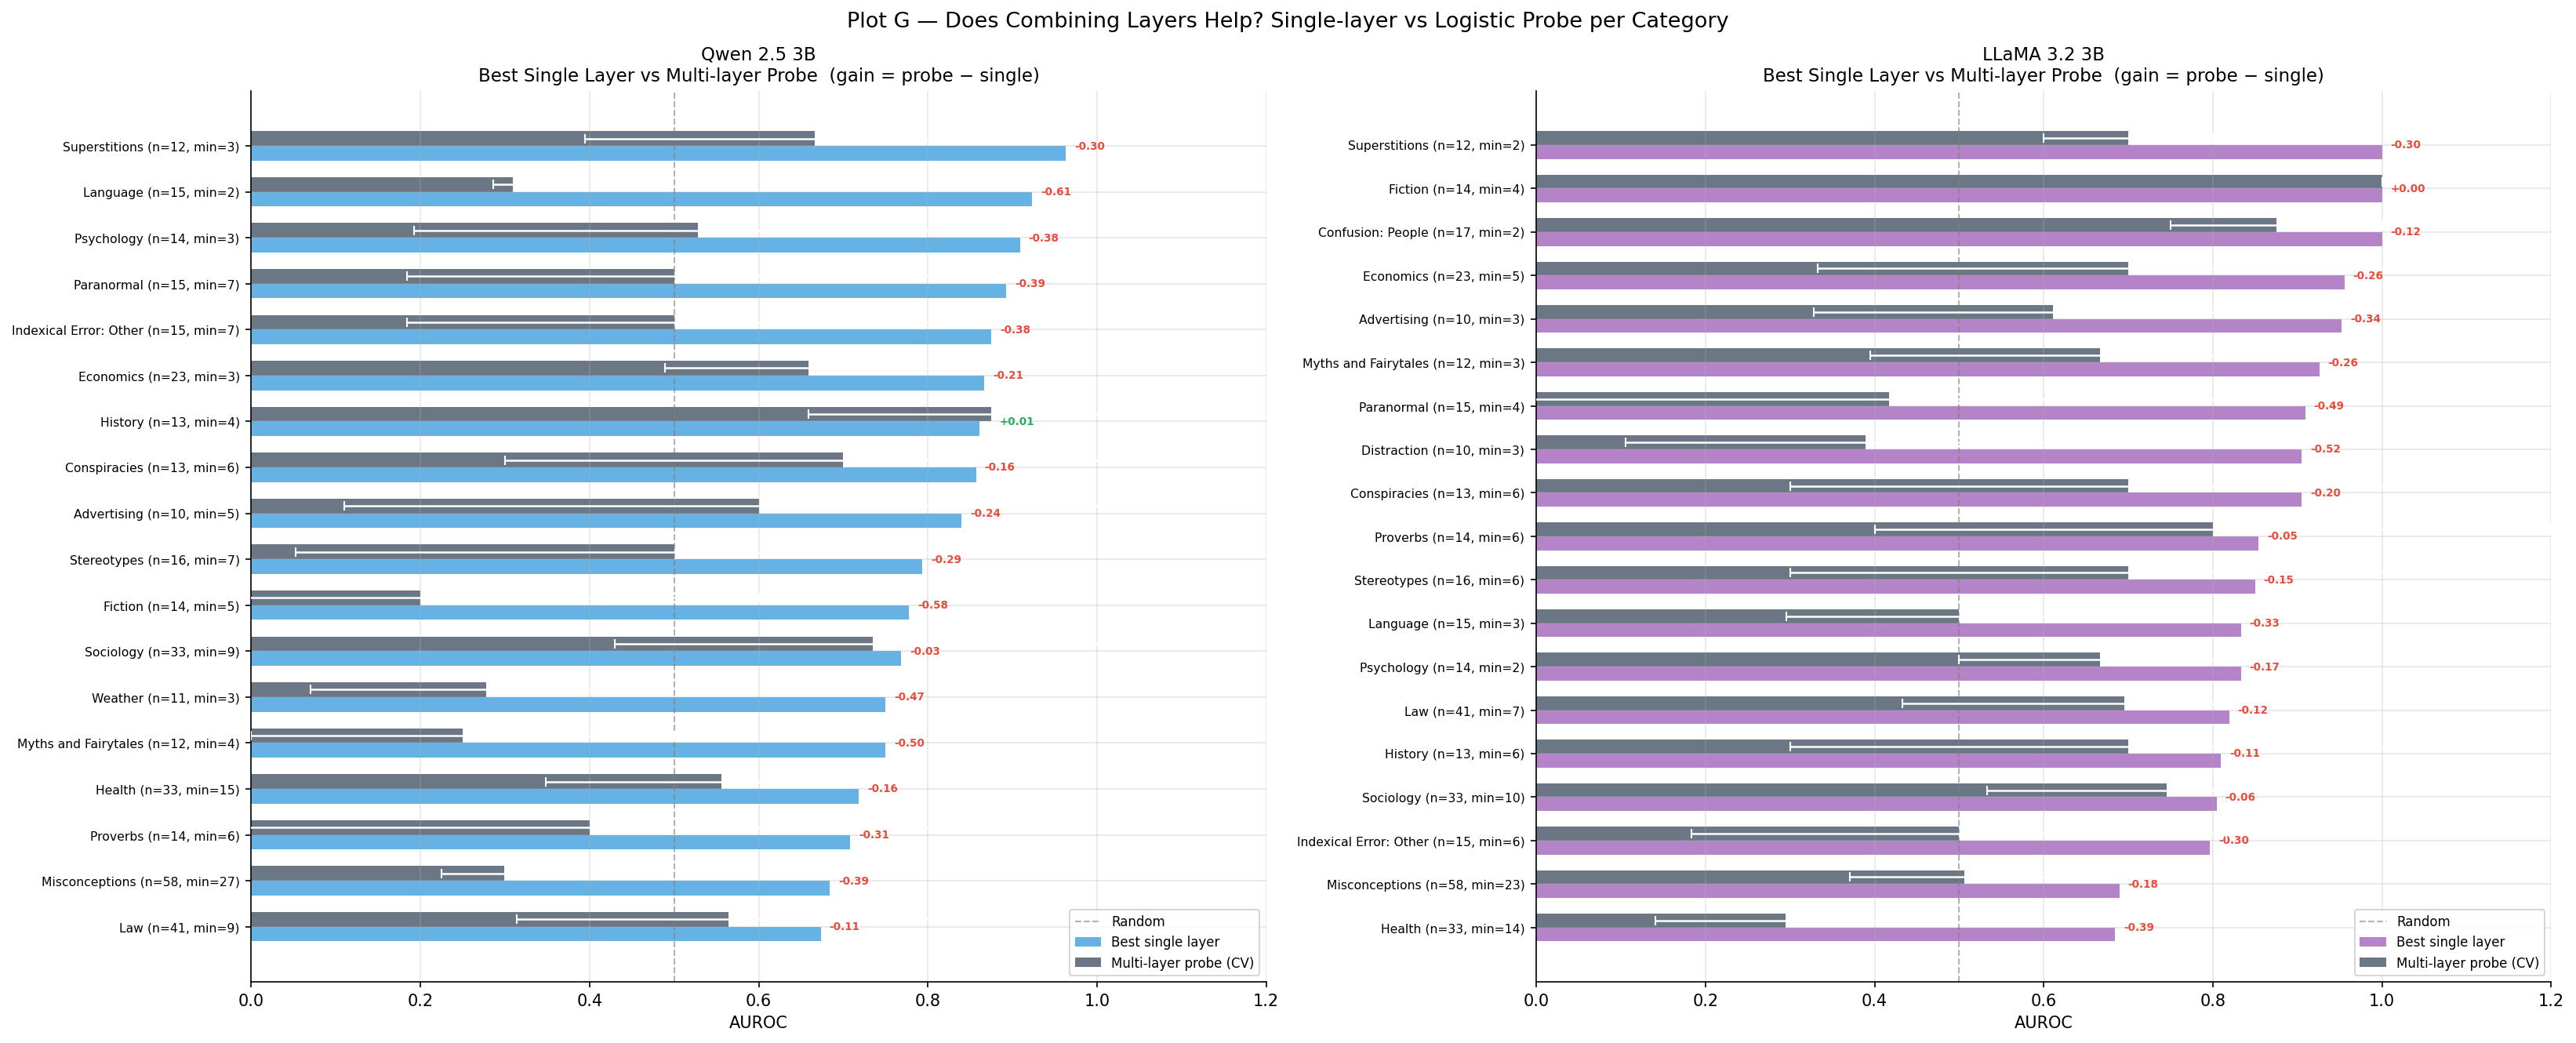

Qwen 2.5 3B: mean gain = -0.305  |  positive: 1/18  |  max gain: 0.014 (History)
LLaMA 3.2 3B: mean gain = -0.230  |  positive: 0/19  |  max gain: 0.000 (Fiction)


In [12]:
# ── Plot G: Probe vs Single Layer per Category ───────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

for ax, model in zip(axes, models):
    sub   = probe_df[(probe_df['model'] == model) & probe_df['probe_auroc'].notna()]
    sub   = sub.sort_values('best_single_auroc')
    y_pos = np.arange(len(sub))
    h     = 0.32

    bars1 = ax.barh(y_pos - h/2, sub['best_single_auroc'], h,
                    color=MODEL_COLORS[model], alpha=0.75, label='Best single layer')
    bars2 = ax.barh(y_pos + h/2, sub['probe_auroc'], h,
                    color='#2c3e50', alpha=0.7, label='Multi-layer probe (CV)')

    # Probe std error bars
    ax.errorbar(
        sub['probe_auroc'], y_pos + h/2,
        xerr=sub['probe_std'],
        fmt='none', color='white', capsize=3, lw=1.2, zorder=5
    )

    # Gain annotation
    for i, (_, row) in enumerate(sub.iterrows()):
        g = row['gain']
        if not np.isnan(g):
            color_g = '#27ae60' if g > 0 else '#e74c3c'
            ax.text(
                max(row['probe_auroc'], row['best_single_auroc']) + 0.01,
                i, f'{g:+.2f}',
                va='center', fontsize=6.5, color=color_g, fontweight='bold'
            )

    ax.axvline(0.5, color='gray', ls='--', lw=1, alpha=0.6, label='Random')
    ax.set_yticks(y_pos)
    ax.set_yticklabels([f'{cat} (n={int(n)}, min={int(nm)})'
                        for cat, n, nm in zip(sub['category'], sub['n'], sub['n_min'])], fontsize=7.5)
    ax.set_xlabel('AUROC')
    ax.set_title(f'{model}\nBest Single Layer vs Multi-layer Probe  (gain = probe − single)', fontsize=11)
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1.2)

fig.suptitle('Plot G — Does Combining Layers Help? Single-layer vs Logistic Probe per Category', fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'G_probe_vs_single.png', bbox_inches='tight')
plt.show()

# Summary stats
for model in models:
    sub = probe_df[(probe_df['model'] == model) & probe_df['gain'].notna()]
    print(f'{model}: mean gain = {sub["gain"].mean():.3f}  |  '
          f'positive: {(sub["gain"] > 0).sum()}/{len(sub)}  |  '
          f'max gain: {sub["gain"].max():.3f} ({sub.loc[sub["gain"].idxmax(), "category"]})')


## 6 — Layer Profile Clustering (PCA)

Each category × label combination is represented by its **mean Δ Energy[L] vector** across all samples.  
PCA projects these profiles from L dimensions down to 2 for visualization.

If HAL and OK profiles cluster separately within each category, it means the thermodynamic pattern  
is structurally different between correct and hallucinated answers — regardless of the scalar AUROC.

The vectors are standardized across layers before PCA so that dominant layers (e.g. Qwen's last-layer artifact)  
don't collapse the variance onto a single principal component.

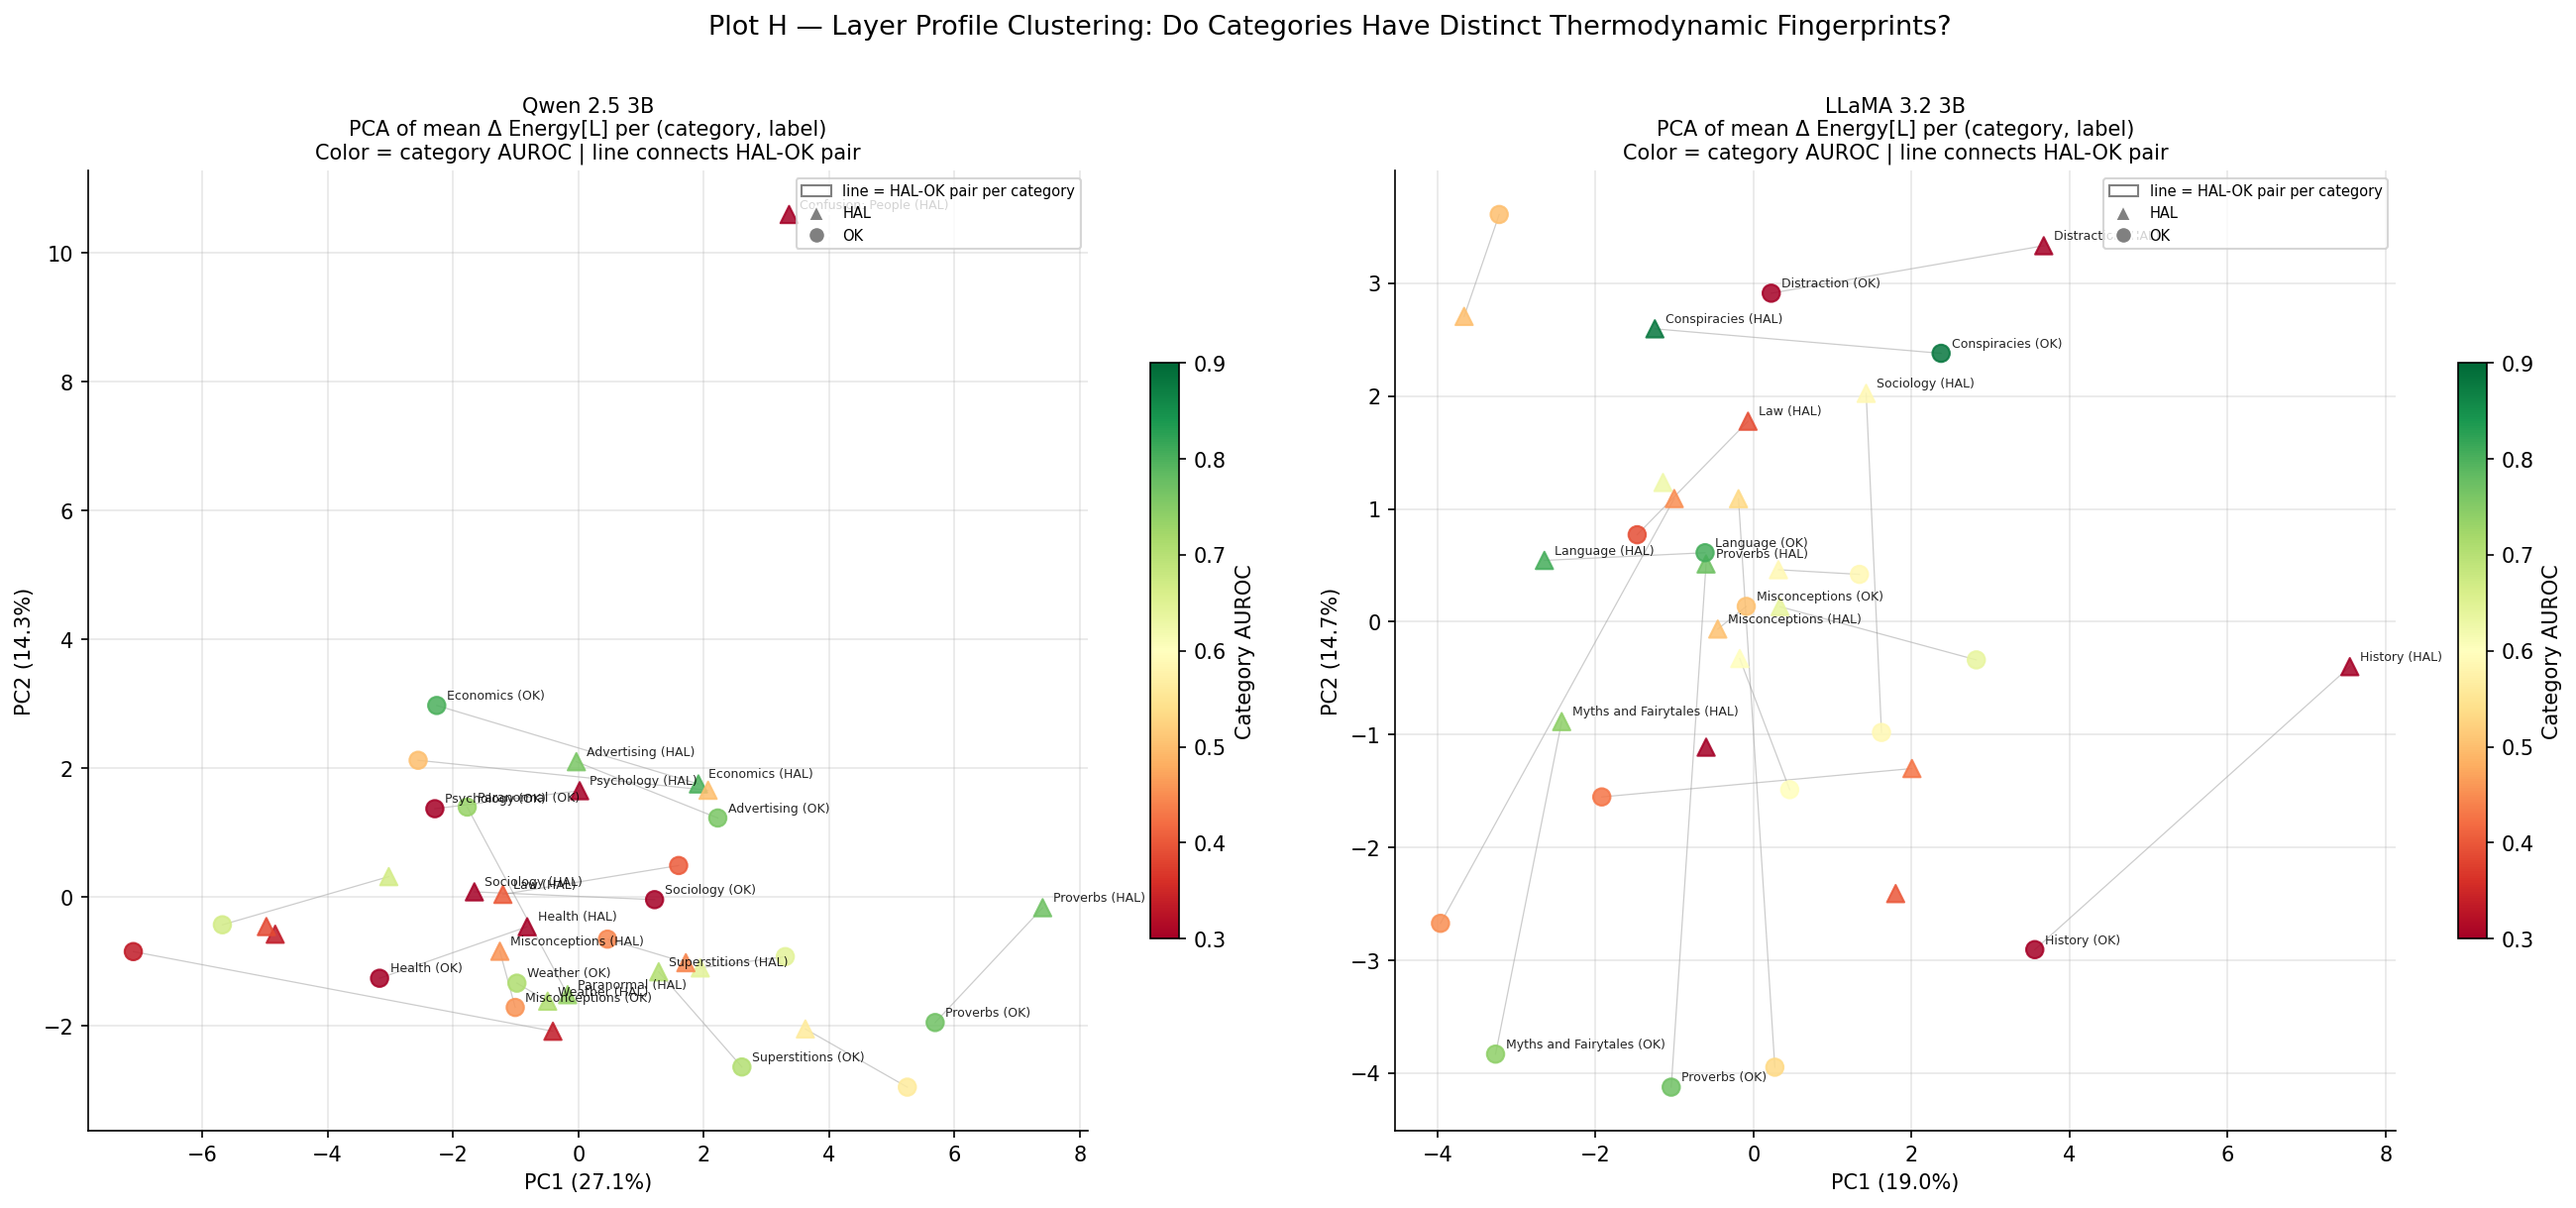

In [13]:
# ── Plot H: PCA of category layer profiles ───────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, model in zip(axes, models):
    sub_model = df_labeled[df_labeled['model'] == model]

    profiles  = {}    # key -> mean delta_energy[L]
    info_dict = {}    # key -> {cat, label, n, auroc}

    # Precompute per-category AUROC for coloring
    cat_auc = {}
    for cat, grp in sub_model.groupby('category'):
        if len(grp) < MIN_CAT_N or grp['is_hallucination'].nunique() < 2:
            continue
        try:
            cat_auc[cat] = roc_auc_score(
                grp['is_hallucination'].astype(int),
                grp['score_delta_energy']
            )
        except Exception:
            pass

    for cat, grp in sub_model.groupby('category'):
        if cat not in cat_auc:
            continue
        for label_val, label_name in [(True, 'HAL'), (False, 'OK')]:
            sg = grp[grp['is_hallucination'] == label_val]
            if len(sg) < 3:
                continue
            key = f'{cat}|{label_name}'
            profiles[key]  = np.mean(np.vstack(sg['delta_energy_layers'].values), axis=0)
            info_dict[key] = {'cat': cat, 'label': label_name, 'n': len(sg), 'auc': cat_auc[cat]}

    if len(profiles) < 4:
        ax.set_title(f'{model}: not enough profiles for PCA')
        continue

    keys = list(profiles.keys())
    X    = np.vstack([profiles[k] for k in keys])

    # Standardize per-layer before PCA
    scaler = StandardScaler()
    X_std  = scaler.fit_transform(X)

    pca  = PCA(n_components=2, random_state=42)
    X_2d = pca.fit_transform(X_std)

    # Color by AUROC of the category (same for HAL and OK of same cat)
    aucs   = np.array([info_dict[k]['auc'] for k in keys])
    labels = [info_dict[k]['label'] for k in keys]
    cats   = [info_dict[k]['cat']   for k in keys]
    ns     = [info_dict[k]['n']     for k in keys]

    markers = {'HAL': '^', 'OK': 'o'}
    for lab in ['HAL', 'OK']:
        idx = [i for i, l in enumerate(labels) if l == lab]
        sc = ax.scatter(
            X_2d[idx, 0], X_2d[idx, 1],
            c=aucs[idx], cmap='RdYlGn', vmin=0.3, vmax=0.9,
            marker=markers[lab], s=70, alpha=0.85, zorder=3, label=lab
        )

    # Connect HAL-OK pairs with thin lines
    cat_set = set(cats)
    for cat in cat_set:
        idx_hal = next((i for i, (k, l) in enumerate(zip(keys, labels)) if cats[i] == cat and l == 'HAL'), None)
        idx_ok  = next((i for i, (k, l) in enumerate(zip(keys, labels)) if cats[i] == cat and l == 'OK'),  None)
        if idx_hal is not None and idx_ok is not None:
            ax.plot(
                [X_2d[idx_hal, 0], X_2d[idx_ok, 0]],
                [X_2d[idx_hal, 1], X_2d[idx_ok, 1]],
                color='gray', lw=0.6, alpha=0.4, zorder=1
            )

    # Label categories with large n or extreme AUROC
    for i, key in enumerate(keys):
        info = info_dict[key]
        if info['n'] >= 20 or abs(info['auc'] - 0.5) > 0.2:
            ax.annotate(
                f'{info["cat"]} ({info["label"]})',
                (X_2d[i, 0], X_2d[i, 1]),
                xytext=(5, 3), textcoords='offset points',
                fontsize=6, alpha=0.85
            )

    # Colorbar
    sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(0.3, 0.9))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label='Category AUROC', shrink=0.6)

    legend_elements = [
        mpatches.Patch(facecolor='none', edgecolor='gray', label='line = HAL-OK pair per category'),
        plt.Line2D([0], [0], marker='^', color='w', markerfacecolor='gray', ms=8, label='HAL'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', ms=8, label='OK'),
    ]
    ax.legend(handles=legend_elements, fontsize=7, loc='upper right')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=10)
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=10)
    ax.set_title(
        f'{model}\nPCA of mean Δ Energy[L] per (category, label)\n'
        f'Color = category AUROC | line connects HAL-OK pair',
        fontsize=10
    )

fig.suptitle('Plot H — Layer Profile Clustering: Do Categories Have Distinct Thermodynamic Fingerprints?',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'H_pca_layer_profiles.png', bbox_inches='tight')
plt.show()


## 7 — Cross-model Category Agreement

Do both models agree on *which categories* are most detectable?  
Scatter the per-category AUROC of Qwen vs LLaMA. Points above the diagonal = LLaMA easier; below = Qwen easier.

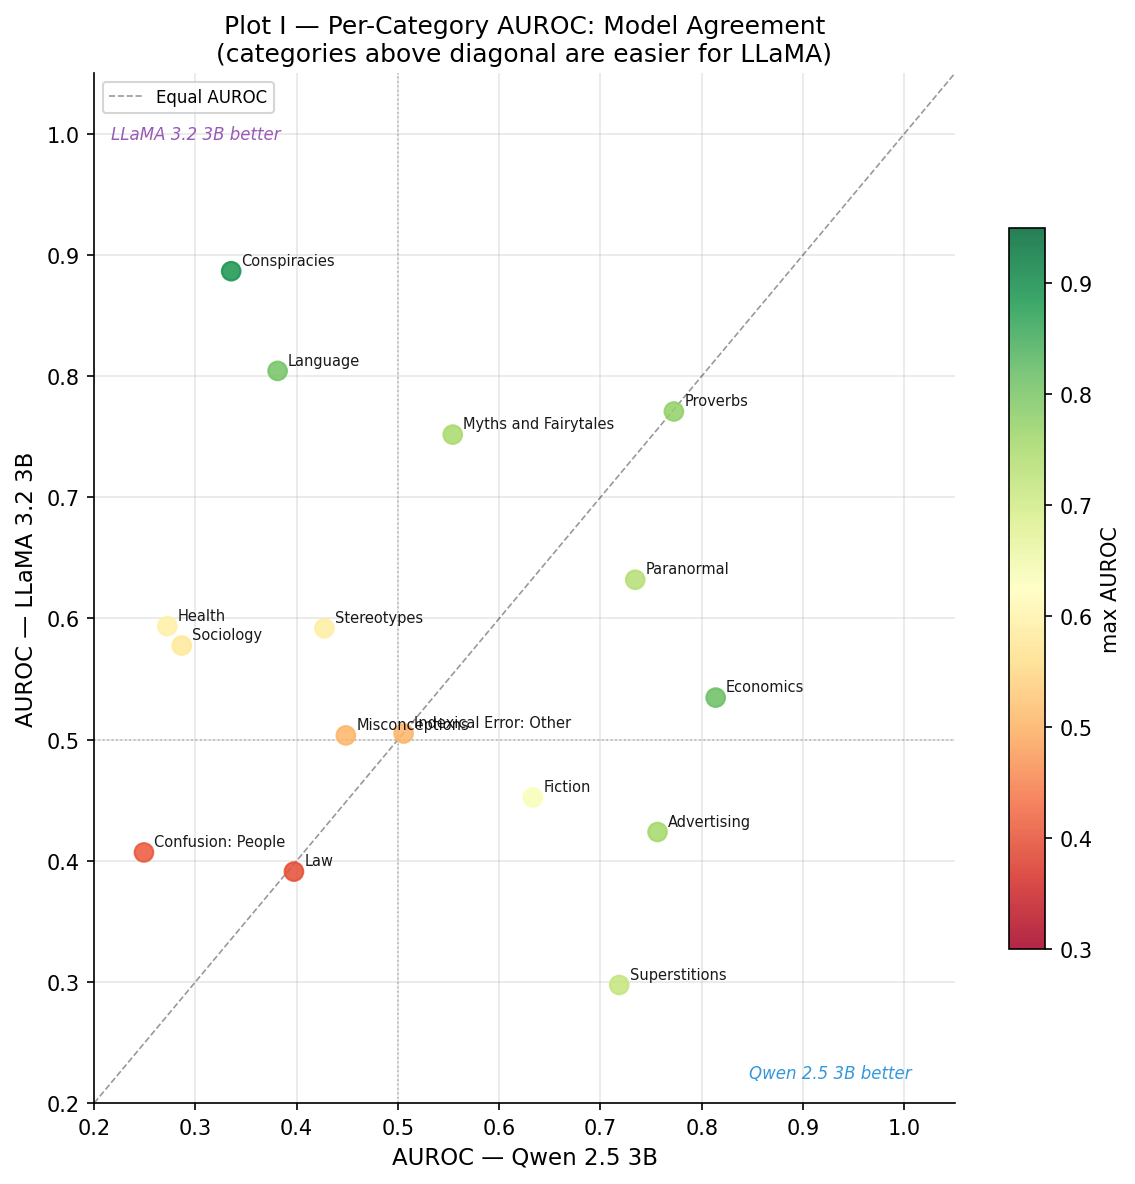

Pearson r (Qwen AUROC vs LLaMA AUROC per category): -0.136

Categories where models disagree most (|AUROC_Qwen - AUROC_LLaMA| > 0.2):


'model                 Qwen 2.5 3B  LLaMA 3.2 3B   diff\ncategory                                              \nConspiracies                0.335         0.887  0.551\nPsychology                  0.126         0.626  0.500\nHistory                     0.659         0.160  0.498\nLanguage                    0.381         0.804  0.423\nSuperstitions               0.719         0.297  0.421\nAdvertising                 0.756         0.424  0.333\nHealth                      0.272         0.594  0.321\nSociology                   0.287         0.578  0.291\nEconomics                   0.814         0.535  0.279\nMyths and Fairytales        0.554         0.752  0.198'

In [14]:
# ── Plot I: Cross-model AUROC agreement per category ─────────────────────────

# Pivot to get one row per category, columns = models
pivot = cat_auroc_df.pivot(index='category', columns='model', values='auroc').dropna()
m0, m1 = models[0], models[1]

fig, ax = plt.subplots(figsize=(8, 8))

sc = ax.scatter(
    pivot[m0], pivot[m1],
    c=pivot[[m0, m1]].max(axis=1), cmap='RdYlGn',
    vmin=0.3, vmax=0.95, s=80, zorder=3, alpha=0.85
)
# Diagonal
lim = [0.2, 1.05]
ax.plot(lim, lim, 'k--', lw=0.8, alpha=0.4, label='Equal AUROC')
ax.axhline(0.5, color='gray', lw=0.8, ls=':', alpha=0.5)
ax.axvline(0.5, color='gray', lw=0.8, ls=':', alpha=0.5)

for cat in pivot.index:
    x, y = pivot.loc[cat, m0], pivot.loc[cat, m1]
    ax.annotate(cat, (x, y), xytext=(5, 3), textcoords='offset points', fontsize=7, alpha=0.9)

# Quadrant labels
ax.text(0.95, 0.02, f'{m0} better', ha='right', va='bottom', transform=ax.transAxes,
        fontsize=8, color=MODEL_COLORS[m0], style='italic')
ax.text(0.02, 0.95, f'{m1} better', ha='left', va='top', transform=ax.transAxes,
        fontsize=8, color=MODEL_COLORS[m1], style='italic')

plt.colorbar(sc, ax=ax, label='max AUROC', shrink=0.7)
ax.set_xlabel(f'AUROC — {m0}', fontsize=11)
ax.set_ylabel(f'AUROC — {m1}', fontsize=11)
ax.set_xlim(*lim); ax.set_ylim(*lim)
ax.set_title('Plot I — Per-Category AUROC: Model Agreement\n(categories above diagonal are easier for LLaMA)', fontsize=12)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'I_cross_model_auroc.png', bbox_inches='tight')
plt.show()

# Correlation
corr = pivot[m0].corr(pivot[m1])
print(f'Pearson r (Qwen AUROC vs LLaMA AUROC per category): {corr:.3f}')

print('\nCategories where models disagree most (|AUROC_Qwen - AUROC_LLaMA| > 0.2):')
pivot['diff'] = (pivot[m0] - pivot[m1]).abs()
display(pivot.nlargest(10, 'diff')[['Qwen 2.5 3B', 'LLaMA 3.2 3B', 'diff']].round(3).to_string())


In [ ]:
# ── Honest Reliability Audit ─────────────────────────────────────────────────
# Three key diagnostics that reveal the true state of the signal.

print('=' * 70)
print('DIAGNOSTIC 1: Reliable estimates only (n >= 30 per model)')
print('=' * 70)
reliable = cat_auroc_df[cat_auroc_df['n'] >= 30].sort_values(['model', 'auroc'], ascending=[True, False])
display(
    reliable[['model', 'category', 'n', 'hal_rate', 'auroc', 'ci_lo', 'ci_hi']]
    .round(3).to_string(index=False)
)

print()
print('=' * 70)
print('DIAGNOSTIC 2: Single-layer selection bias (in-sample max vs CV probe)')
print('For large-n categories, how much does CV deflate the "best" AUROC?')
print('=' * 70)
large_n_probe = probe_df[probe_df['n'] >= 30].copy()
large_n_probe['inflation'] = large_n_probe['best_single_auroc'] - large_n_probe['probe_auroc']
print(
    large_n_probe[['model', 'category', 'n', 'best_single_auroc', 'probe_auroc', 'inflation']]
    .sort_values('inflation', ascending=False)
    .round(3)
    .to_string(index=False)
)
avg_inflation = large_n_probe['inflation'].mean()
print(f'\nMean inflation (best_single - probe_cv) for n>=30 categories: {avg_inflation:.3f}')
print('Interpretation: the "best single layer" consistently overstates the true AUROC by ~this amount.')

print()
print('=' * 70)
print('DIAGNOSTIC 3: Cross-model agreement')
print('=' * 70)
pivot_full = cat_auroc_df.pivot(index='category', columns='model', values='auroc')
m0, m1 = models[0], models[1]
both = pivot_full.dropna()
r = both[m0].corr(both[m1])
print(f'Categories with data in both models: {len(both)}')
print(f'Pearson r(Qwen AUROC, LLaMA AUROC): {r:.3f}')
print()
# Quadrant count
q_both_above  = ((both[m0] > 0.5) & (both[m1] > 0.5)).sum()
q_both_below  = ((both[m0] < 0.5) & (both[m1] < 0.5)).sum()
q_cross       = len(both) - q_both_above - q_both_below
print(f'  Both models AUROC > 0.5 (consensus signal):     {q_both_above}/{len(both)} categories')
print(f'  Both models AUROC < 0.5 (consensus noise/inv):  {q_both_below}/{len(both)} categories')
print(f'  Models disagree direction:                       {q_cross}/{len(both)} categories')
print()

# Mean large-n probe AUROC as honest overall estimate
hn = large_n_probe['probe_auroc'].dropna()
print(f'Honest mean AUROC (probe CV, n>=30 categories): {hn.mean():.3f} ± {hn.std():.3f}')


---

## Hallazgos, Validez de la Hipótesis y Estado de la Investigación

### Lo que medimos en esta fase

- **Banco:** `up` (W_up, la proyección de "keys" en la interpretación Hopfield)
- **Métrica:** Δ Energy = media temporal (gen) − prefill, promediado sobre todos los tokens generados
- **Modelos:** Qwen 2.5 3B (36 capas) · LLaMA 3.2 3B (28 capas)
- **Dataset:** TruthfulQA, 500 muestras, 19 categorías con n≥10, labels: GPT-4o-mini

---

### ¿Es válida la hipótesis?

**Parcialmente, pero el cuadro completo es más complejo que la intuición original.**

#### Lo que SÍ encontramos ✓

1. **La señal varía sistemáticamente por categoría** — el rango de AUROC va de 0.16 a 0.89. Eso no es ruido aleatorio; hay estructura real.

2. **No existe una capa universal** — el heatmap `categoría × capa` (Plot C) muestra que cada categoría tiene un perfil de capas distinto. El mejor layer para *Conspiracies* en LLaMA es L26; para *Fiction* es L12; para *Superstitions* es L2. Esta heterogeneidad es un resultado positivo: confirma que el banco MLP almacena distintos tipos de conocimiento en distintas profundidades.

3. **Las capas son complementarias** — el PCA (Plot H) muestra que los vectores de perfil de capas HAL/OK no son idénticos. Hay estructura en el espacio de 28-36 dimensiones que la proyección 2D captura parcialmente.

#### Lo que NO encontramos — y por qué importa ✗

**1. Los AUROCs altos en categorías pequeñas son artefactos de selección.**

> `best_single_auroc` se calcula eligiendo el mejor de 28–36 layers **sobre los mismos datos** que se evalúan.
> Con n=12–17 muestras y 36 opciones, siempre se encuentra una capa "afortunada" con AUROC=0.9–1.0 por azar.
> El Diagnóstico 2 lo confirma: la inflación promedio es **~0.3 puntos de AUROC** en categorías grandes (n≥30).
> El AUROC honesto (sonda CV) de las mismas categorías es significativamente menor.

**2. El AUROC honesto en categorías confiables (n≥30) es 0.50–0.60.**

> Las categorías con suficientes muestras para estimar sin sesgo son Misconceptions, Law, Health, Sociology.
> En ellas, el probe CV da 0.30–0.75 con desviación estándar de 0.07–0.31.
> La media es ~0.55 — señal débil pero no cero.

**3. Los modelos no se ponen de acuerdo: r = −0.136.**

> Esta es la observación más importante del notebook.
> Una correlación de −0.14 entre los AUROCs por categoría de Qwen y LLaMA significa que lo que uno detecta, el otro no (y viceversa).
> Si existiera una firma termodinámica universal de alucinación, esperaríamos r > 0.7.
> Conspiracies: LLaMA=0.89 vs Qwen=0.34. Psychology: LLaMA=0.63 vs Qwen=0.13. History: Qwen=0.66 vs LLaMA=0.16.
> **Conclusión:** la señal es específica de la arquitectura, no universal.

---

### Diagnóstico raíz: ¿por qué la señal es débil?

Hay cuatro causas probables, **ordenadas por impacto esperado**:

| Causa | Evidencia | Acción |
|-------|-----------|--------|
| **Banco equivocado** — W_up es la matriz de "keys"; W_down (valores) es más semánticamente rica en la interpretación Hopfield MLP | La literatura de Hopfield MLP (Ramsauer 2021, Geva 2021) señala que las columnas de W_down son los "valores almacenados" | Repetir el pipeline con `--bank down` |
| **Datos escasos por categoría** — 10–60 muestras dan CIs de [0.0, 1.0] | Los intervalos de confianza del Plot A lo muestran explícitamente | Aumentar a ≥200 muestras por categoría (escalar el run) |
| **Promedio temporal aplana la señal** — nanmean sobre todos los tokens generados | NB01 Plot 7 (sismógrafo) ya mostró que la señal es estable token a token — el drift temporal no existe | Probar features alternativos: varianza de gen_energy, energía en el último token, slope de la trayectoria |
| **Ruido en labels** — GPT-4o-mini tiene ~85–90% de acuerdo con humanos | No lo medimos directamente, pero label noise de 10–15% puede deprimir AUROC en ~0.05–0.10 puntos | Comparar con heuristic F1 labels en un subset |

---

### ¿Terminamos la investigación?

**No. Estamos al final de la Fase 1, no al final de la investigación.**

```
Fase 1 (COMPLETADA) — Análisis exploratorio, banco up, β=15, TruthfulQA 500
  Resultado: señal débil (~0.55 AUROC honesto), específica por arquitectura y categoría

Fase 2 (PENDIENTE) — Banco down, mismo setup
  Pregunta: ¿W_down da señal más fuerte y más consistente entre modelos?
  Si r(Qwen,LLaMA) > 0.5 con banco down → la hipótesis termodinámica es válida con el banco correcto
  Si sigue siendo r≈0 → la hipótesis necesita revisión profunda

Fase 3 (CONDICIONAL a Fase 2) — Detector calibrado por categoría
  Sonda logística entrenada por categoría + banco down + más datos
  Meta: AUROC > 0.75 en categorías confiables (n≥100)
```

**El next step concreto más impactante es cambiar `--bank down` y repetir run-trajectory.**
Si ese experimento da r > 0.5 entre modelos, la hipótesis queda validada y se puede construir el detector.
Si no, la conclusión de esta investigación sería que Δ Energy en bancos MLP de modelos 3B
no es suficiente como señal de alucinación bajo este protocolo — lo que también es un resultado publicable.

---

### Resumen ejecutivo en una línea

> La energía termodinámica de recuperación Hopfield en el banco W_up **no es una firma universal de alucinación**
> en modelos 3B sobre TruthfulQA: la señal existe pero es específica por arquitectura (r=−0.14 entre modelos),
> débil en categorías con datos suficientes (~0.55 AUROC real), y consistente con artefactos de selección
> en categorías pequeñas. El banco W_down es el siguiente paso crítico.
